In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation")  # <<< updated path here to refer to the implementation of OT-Impute and other imputation methods
import utils
import Inject_Missing_Values
import Updated_OT
import imputers
import imputers_fullyActive

In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from Inject_Missing_Values import *
# Import your original OTImputer
from imputers import OTimputer
from Updated_OT import OTimputerDropOutNoise
from imputers_fullyActive import OTimputerFullyActive

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)

Loading the data

In [5]:
data = fetch_openml(name="credit-g", version=1, as_frame=True)
X_full = data.data.copy()

In [6]:
# Convert categorical to numerical codes
for col in X_full.select_dtypes(include=['category', 'object']).columns:
    X_full[col] = X_full[col].astype('category').cat.codes

In [7]:
scaler = MinMaxScaler() #data [0,1]
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [8]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [9]:
print(GroundTruth)

     checking_status  duration  credit_history   purpose  credit_amount  \
0           0.333333  0.029412            0.25  0.777778       0.050567   
1           0.000000  0.647059            0.75  0.777778       0.313690   
2           1.000000  0.117647            0.25  0.444444       0.101574   
3           0.333333  0.558824            0.75  0.555556       0.419941   
4           0.333333  0.294118            0.50  0.111111       0.254209   
..               ...       ...             ...       ...            ...   
995         1.000000  0.117647            0.75  0.555556       0.081765   
996         0.333333  0.382353            0.75  0.222222       0.198470   
997         1.000000  0.117647            0.75  0.777778       0.030483   
998         0.333333  0.602941            0.75  0.777778       0.087763   
999         0.000000  0.602941            0.25  0.222222       0.238032   

     savings_status  employment  installment_commitment  personal_status  \
0               1.0    

In [10]:
GroundTruth.nunique()

checking_status             4
duration                   33
credit_history              5
purpose                    10
credit_amount             921
savings_status              5
employment                  5
installment_commitment      4
personal_status             4
other_parties               3
residence_since             4
property_magnitude          4
age                        53
other_payment_plans         3
housing                     3
existing_credits            4
job                         4
num_dependents              2
own_telephone               2
foreign_worker              2
dtype: int64

In [13]:
print("checking_status",GroundTruth['checking_status'].unique())
print("duration",GroundTruth['duration'].unique())
print("credit_history",GroundTruth['credit_history'].unique())
print("purpose",GroundTruth['purpose'].unique())
print("credit_amount",GroundTruth["credit_amount"].unique())
print("savings_status",GroundTruth['savings_status'].unique())
print("employment",GroundTruth['employment'].unique())
print("installment_commitment",GroundTruth['installment_commitment'].unique())
print("personal_status",GroundTruth['personal_status'].unique())
print("other_parties",GroundTruth['other_parties'].unique())
print("residence_since",GroundTruth['residence_since'].unique())
print("property_magnitude",GroundTruth['property_magnitude'].unique())
print("age",GroundTruth['age'].unique())
print("other_payment_plans",GroundTruth['other_payment_plans'].unique())
print("housing",GroundTruth['housing'].unique())
print("existing_credits",GroundTruth['existing_credits'].unique())
print("job",GroundTruth['job'].unique())
print("num_dependents",GroundTruth['num_dependents'].unique())
print("own_telephone",GroundTruth['own_telephone'].unique())
print("foreign_worker",GroundTruth['foreign_worker'].unique())

checking_status [0.33333333 0.         1.         0.66666667]
duration [0.02941176 0.64705882 0.11764706 0.55882353 0.29411765 0.47058824
 0.38235294 0.16176471 0.07352941 0.08823529 0.04411765 0.82352941
 0.20588235 0.60294118 0.10294118 0.33823529 0.05882353 0.73529412
 0.23529412 0.14705882 0.42647059 0.25       0.17647059 0.
 0.63235294 0.13235294 0.26470588 0.51470588 0.35294118 0.01470588
 0.32352941 1.         0.52941176]
credit_history [0.25 0.75 0.5  1.   0.  ]
purpose [0.77777778 0.44444444 0.55555556 0.11111111 0.22222222 0.33333333
 0.         0.88888889 0.66666667 1.        ]
credit_amount [0.05056674 0.31368989 0.10157368 0.41994057 0.25420931 0.48448333
 0.14223616 0.36854848 0.15456146 0.27423792 0.05749972 0.22328601
 0.07246616 0.05221745 0.06344228 0.05678442 0.11962144 0.43039507
 0.67838671 0.17497524 0.10366458 0.13189171 0.10955211 0.08550677
 0.10008804 0.06184659 0.00968416 0.00874876 0.11912622 0.36238583
 0.09150435 0.2074392  0.30901288 0.05579399 0.06734896

Dependecies for MAR & MNAR

In [15]:
mean_age = GroundTruth["age"].mean()
median_employment = GroundTruth["employment"].median()
mean_credithistory = GroundTruth["credit_history"].mean()
mean_residencesince = GroundTruth["residence_since"].mean()
median_property = GroundTruth["property_magnitude"].median()
mean_telephone = GroundTruth["own_telephone"].median()
median_maritalStatus = GroundTruth["personal_status"].median()
mean_credit_amount = GroundTruth["credit_amount"].mean()
median_duration = GroundTruth["duration"].median()
median_checking = GroundTruth["checking_status"].median()
median_savings = GroundTruth["savings_status"].median()
mean_purpose = GroundTruth["purpose"].mean()
mean_job = GroundTruth["job"].mean()
median_housing = GroundTruth["housing"].median()
median_installment = GroundTruth["installment_commitment"].median()
mean_existing_credits = GroundTruth["existing_credits"].mean()

dependencies_mar = {
    "savings_status": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] <= mean_age else 0.2
    },
    "checking_status": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] <= mean_age else 0.2
    },
    "credit_amount": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] > mean_age else 0.2
    },
    "employment": {
        "influencers": ["personal_status"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["personal_status"] <= median_maritalStatus else 0.1
    },
    "duration": {
        "influencers": ["personal_status"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["personal_status"] <= median_maritalStatus else 0.2
    },
    "job": {
        "influencers": ["employment"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["employment"] < median_employment else 0.2
    },
    "purpose": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] <= mean_age else 0.2
    },
    "other_payment_plans": {
        "influencers": ["credit_history"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["credit_history"] < mean_credithistory else 0.2
    },
    "housing": {
        "influencers": ["residence_since"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["residence_since"] >= mean_residencesince else 0.2
    },
    "other_parties": {
        "influencers": ["property_magnitude"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["property_magnitude"] < median_property else 0.2
    },
    "foreign_worker": {
        "influencers": ["own_telephone"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["own_telephone"] > mean_telephone else 0.2
    },
    "num_dependents": {
        "influencers": ["personal_status"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["personal_status"] <= median_maritalStatus else 0.2
    },
    "installment_commitment": {
        "influencers": ["credit_amount"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["credit_amount"] >= mean_credit_amount else 0.2
    },
    "credit_history": {
        "influencers": ["duration"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["duration"] <= median_duration else 0.2
    },
    "residence_since": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] > mean_age else 0.2
    },
    "property_magnitude": {
        "influencers": ["savings_status"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["savings_status"] < median_savings else 0.2
    },
    "personal_status": {
        "influencers": ["job"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["job"] > mean_job else 0.2
    },
    "own_telephone": {
        "influencers": ["housing"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["housing"] > median_housing else 0.2
    },
    "existing_credits": {
        "influencers": ["credit_amount"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["credit_amount"] >= mean_credit_amount else 0.2
    }
    
}


In [17]:
mean_age = GroundTruth["age"].mean()
median_employment = GroundTruth["employment"].median()
mean_credit_history = GroundTruth["credit_history"].mean()
mean_residence_since = GroundTruth["residence_since"].mean()
median_property = GroundTruth["property_magnitude"].median()
mean_telephone = GroundTruth["own_telephone"].median()
median_maritalStatus = GroundTruth["personal_status"].median()
mean_credit_amount = GroundTruth["credit_amount"].mean()
median_duration = GroundTruth["duration"].median()
median_checking = GroundTruth["checking_status"].median()
median_savings = GroundTruth["savings_status"].median()
mean_purpose = GroundTruth["purpose"].mean()
mean_job = GroundTruth["job"].mean()
median_housing = GroundTruth["housing"].median()
median_installment = GroundTruth["installment_commitment"].median()
mean_existing_credits = GroundTruth["existing_credits"].mean()

dependencies_mnar = {
    "savings_status": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["savings_status"] < median_savings else 0.2
    },
    "checking_status": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["checking_status"] < median_checking else 0.2
    },
    "credit_amount": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["credit_amount"] > mean_credit_amount else 0.2
    },
    "employment": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["employment"] < median_employment else 0.2
    },
    "duration": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["duration"] > median_duration else 0.2
    },
    "job": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["job"] > mean_job else 0.2
    },
    "purpose": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["purpose"] <= mean_purpose else 0.2
    },
    "other_payment_plans": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["other_payment_plans"] == 0 else 0.2
    },
    "housing": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["housing"] > median_housing else 0.2
    },
    "other_parties": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["other_parties"] == 0 else 0.2
    },
    "foreign_worker": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["foreign_worker"] == 0 else 0.2
    },
    "num_dependents": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["num_dependents"] > 0 else 0.2
    },
    "installment_commitment": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["installment_commitment"] < median_installment else 0.2
    },
    "credit_history": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["credit_history"] < mean_credit_history else 0.2
    },
    "residence_since": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["residence_since"] > mean_residence_since else 0.2
    },
    "property_magnitude": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["property_magnitude"] < median_property else 0.2
    },
    "personal_status": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["personal_status"] <= median_maritalStatus else 0.2
    },
    "own_telephone": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["own_telephone"] > mean_telephone else 0.2
    },
    "existing_credits": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["existing_credits"] >= mean_existing_credits else 0.2
    },
    "age": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] <= mean_age else 0.2
    }
}


## Running OT-Impute, OT-Rand & Batch-Impute

### MCAR

In [ ]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing
budgets = [0.1, 0.2, 0.3]  # Query 10%, 25%, 50% of missing cells

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}


for missing_rate in missing_rates:
    generator_mcar = Inject_Missing_Values() #missing value generating
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()

    

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mcar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mcar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mcar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mcar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mcar[metric]:
        for method in results_mcar[metric][budget]:
            values = results_mcar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mcar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mcar = df_results_mcar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mcar.columns.name = None
df_results_mcar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mcar.columns]
df_results_mcar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Credit_results_mcar_metrics.csv", index=False)
    


Plotting results...


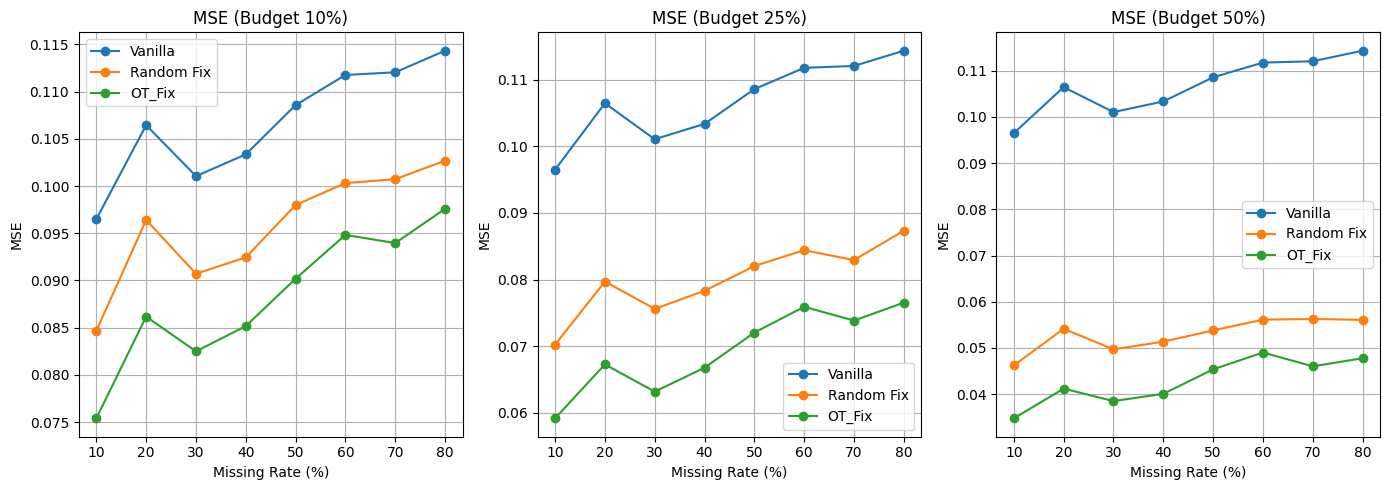

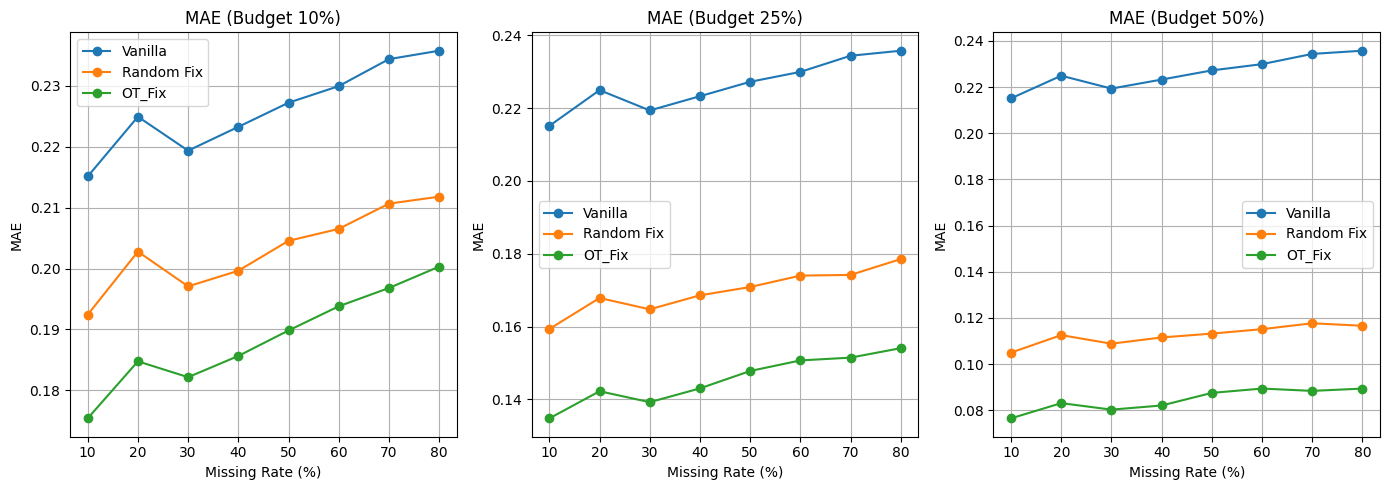

In [13]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["Vanilla"], label="Vanilla", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["RandomFix"], label="Random Fix", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT_Fix"], label="OT_Fix", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

### MAR 

In [ ]:
results_mar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    total_missing_percentage_mar = miss_mar.isnull().sum().sum() / miss_mar.size * 100
    print(f"Total Missing Percentage MAR: {total_missing_percentage_mar:.2f}%")

    missing_percentage = (miss_mar.isnull().sum() / len(miss_mar)) * 100
    print(missing_percentage)

    missing_mask = miss_mar.isna()

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mar[metric]:
        for method in results_mar[metric][budget]:
            values = results_mar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mar = df_results_mar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mar.columns.name = None
df_results_mar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mar.columns]
df_results_mar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Credit_results_mar_metrics.csv", index=False)
    

Total Missing Percentage MAR25: 10.00%
checking_status           12.8
duration                  13.7
credit_history            10.5
purpose                   10.4
credit_amount             10.4
savings_status            10.8
employment                14.8
installment_commitment     8.5
personal_status           12.5
other_parties              9.9
residence_since           10.6
property_magnitude         5.6
age                        0.0
other_payment_plans        9.5
housing                   10.2
existing_credits           9.4
job                        8.4
num_dependents            15.4
own_telephone              7.7
foreign_worker             8.9
dtype: float64
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Total Missing Percentage MAR25: 20.00%
checking_status           24.4
duration                  28.1
credit_history            20.7
purpose                   22.0
credit_amount             19.3
savings_status            22.2
employment       


Plotting results...


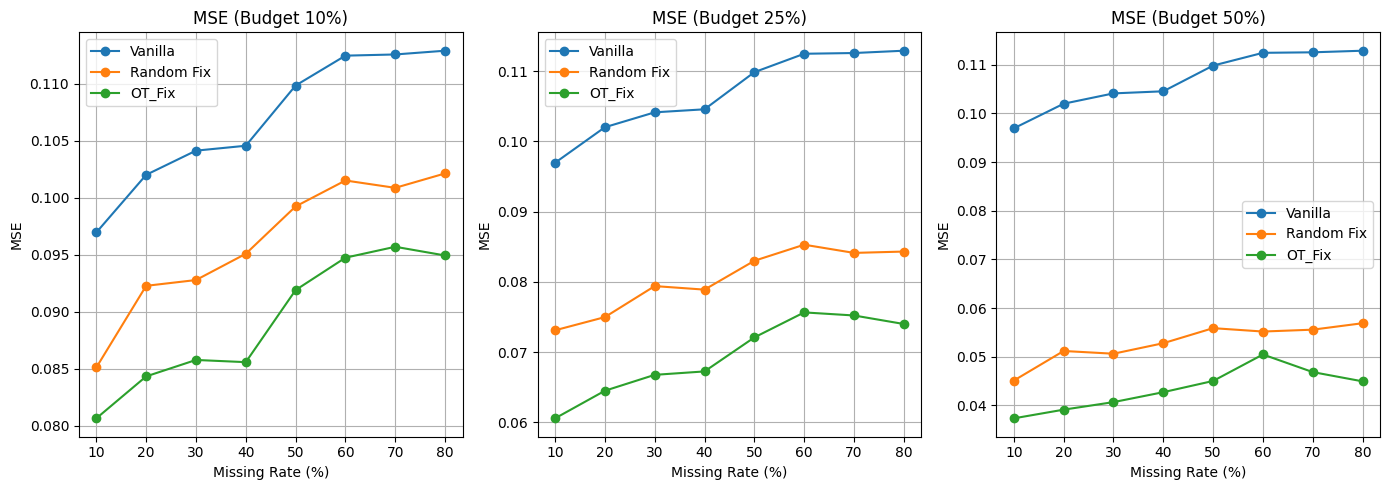

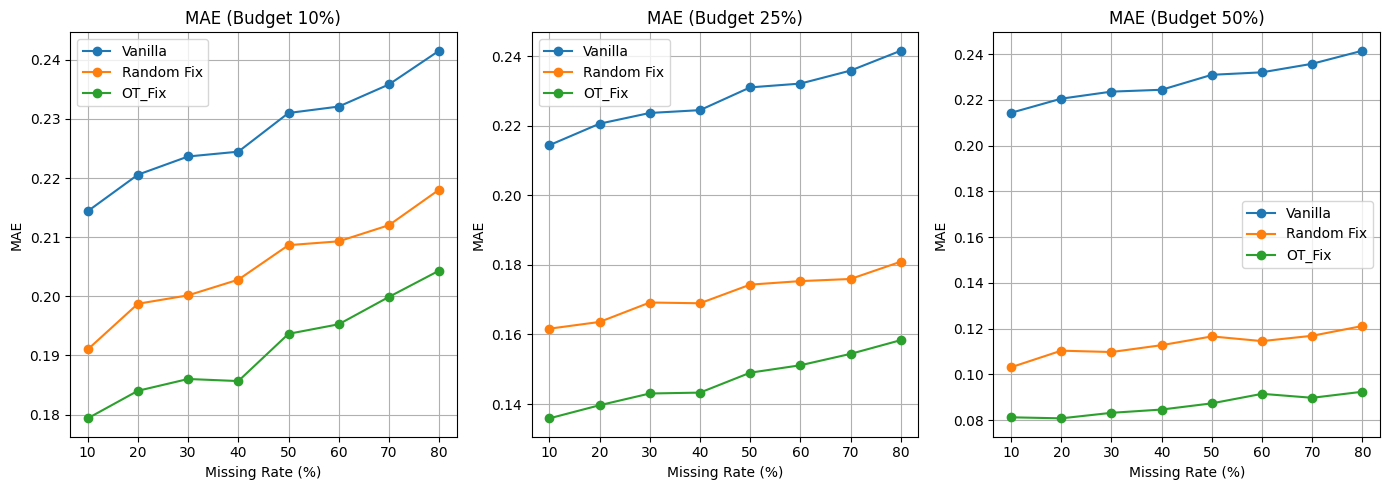

In [16]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["Vanilla"], label="Vanilla", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["RandomFix"], label="Random Fix", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT_Fix"], label="OT_Fix", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()


Plotting combined results...


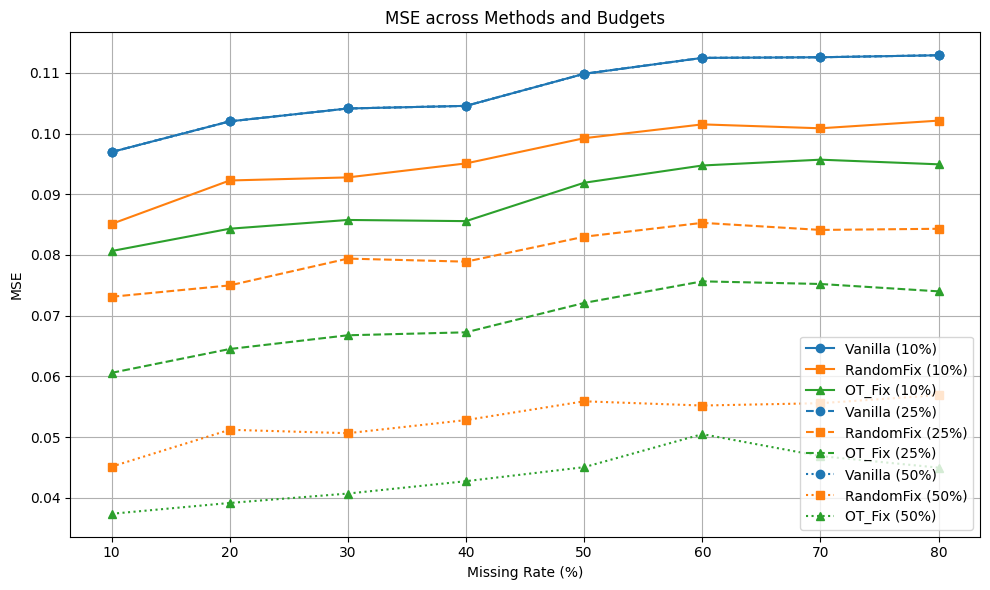

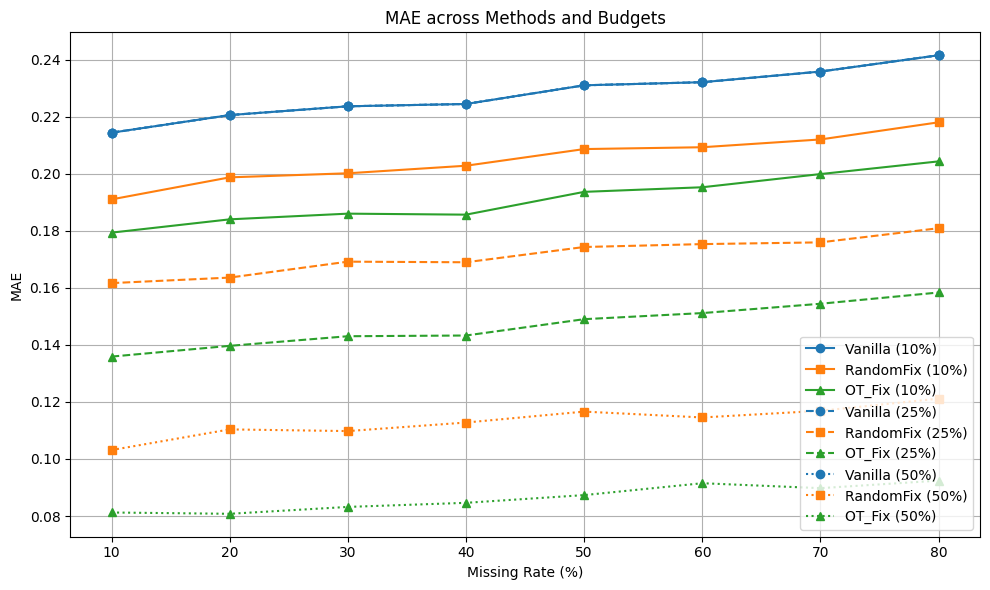

In [17]:
# --------------------------
# Combined Line Plot per Metric
# --------------------------
print("\nPlotting combined results...")

# Define consistent styles
line_styles = {
    0.1: '-',    # Budget 10%
    0.25: '--',  # Budget 25%
    0.5: ':'     # Budget 50%
}

markers = {
    "Vanilla": 'o',
    "RandomFix": 's',
    "OT_Fix": '^'
}

colors = {
    "Vanilla": 'tab:blue',
    "RandomFix": 'tab:orange',
    "OT_Fix": 'tab:green'
}

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(10, 6))

    for budget_fraction in budgets:
        for method in ["Vanilla", "RandomFix", "OT_Fix"]:
            values = results_mar[metric_name][budget_fraction][method]
            plt.plot(
                missing_rates,
                values,
                linestyle=line_styles[budget_fraction],
                marker=markers[method],
                color=colors[method],
                label=f"{method} ({int(budget_fraction*100)}%)"
            )

    plt.xlabel("Missing Rate (%)")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} across Methods and Budgets")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### MNAR

In [19]:
results_mnar = {
    "MSE": {b: {"Vanilla": [], "RandomFix": [], "OT_Fix": []} for b in budgets},
    "MAE": {b: {"Vanilla": [], "RandomFix": [], "OT_Fix": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()

    imputed_runs = []
    for i in range(4):
        print(f"Run {i+1}...")
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter = 1000, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean = np.nanmean(imputed_stack, axis=0)
    imputed_std = np.nanstd(imputed_stack, axis=0)

    # Vanilla OTImputer (same for all budgets)
    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
        std_values = imputed_std[missing_mask.values]

        # Save Vanilla
        results_mnar["MSE"][budget_fraction]["Vanilla"].append(baseline_mse)
        results_mnar["MAE"][budget_fraction]["Vanilla"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = imputed_mean.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["RandomFix"].append(random_fix_mse)
        results_mnar["MAE"][budget_fraction]["RandomFix"].append(random_fix_mae)

        # ActiveOT Fix
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["OT_Fix"].append(active_fix_mse)
        results_mnar["MAE"][budget_fraction]["OT_Fix"].append(active_fix_mae)
    

Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 25%
  -> Budget 50%



Plotting results...


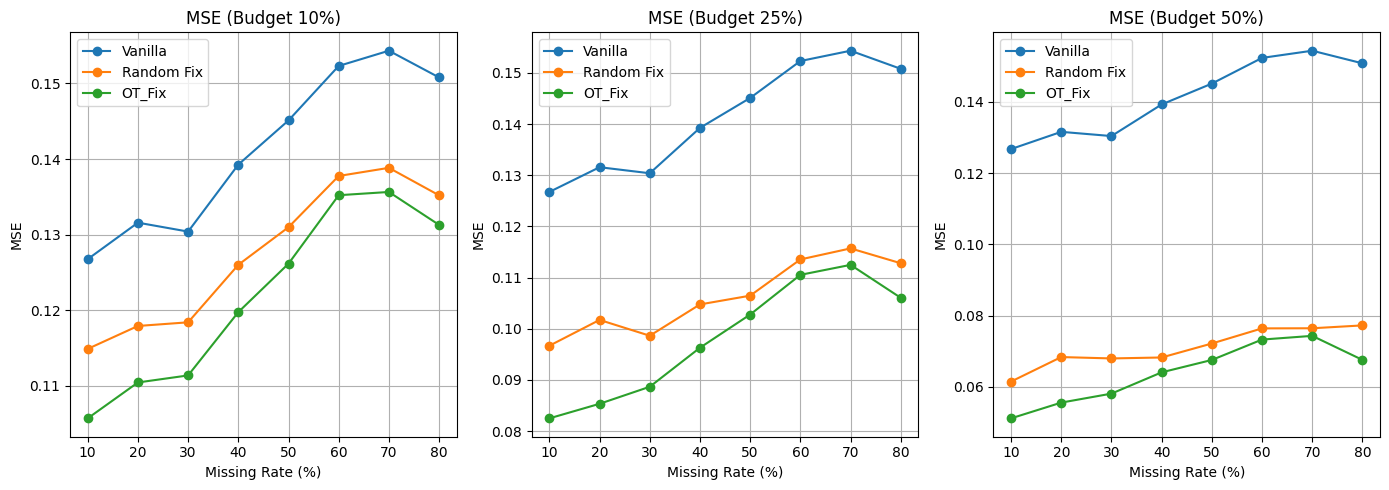

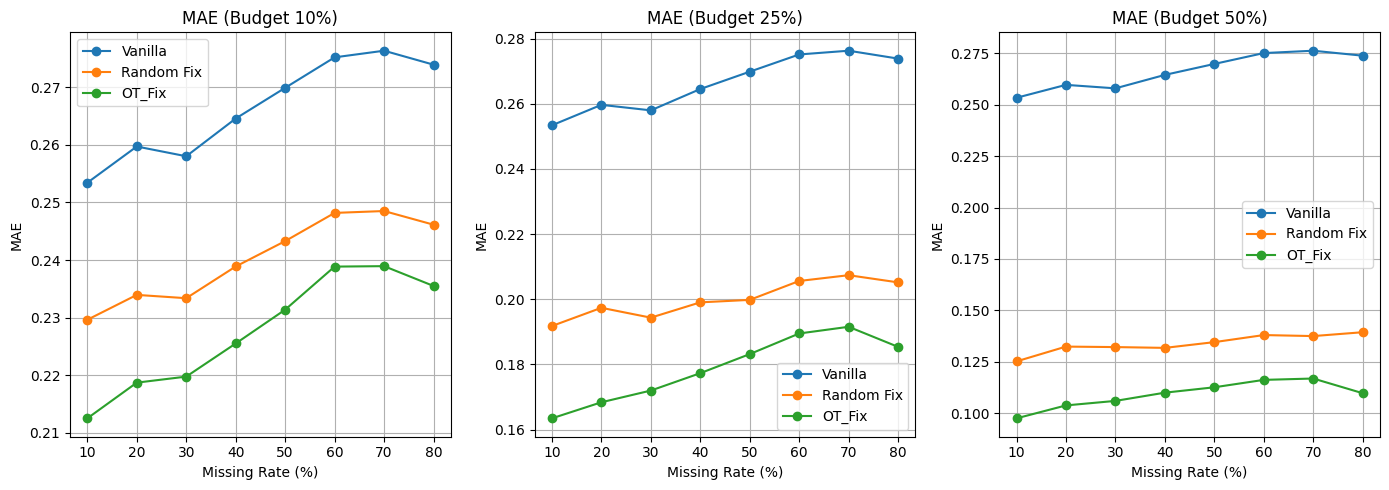

In [20]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["Vanilla"], label="Vanilla", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["RandomFix"], label="Random Fix", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT_Fix"], label="OT_Fix", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

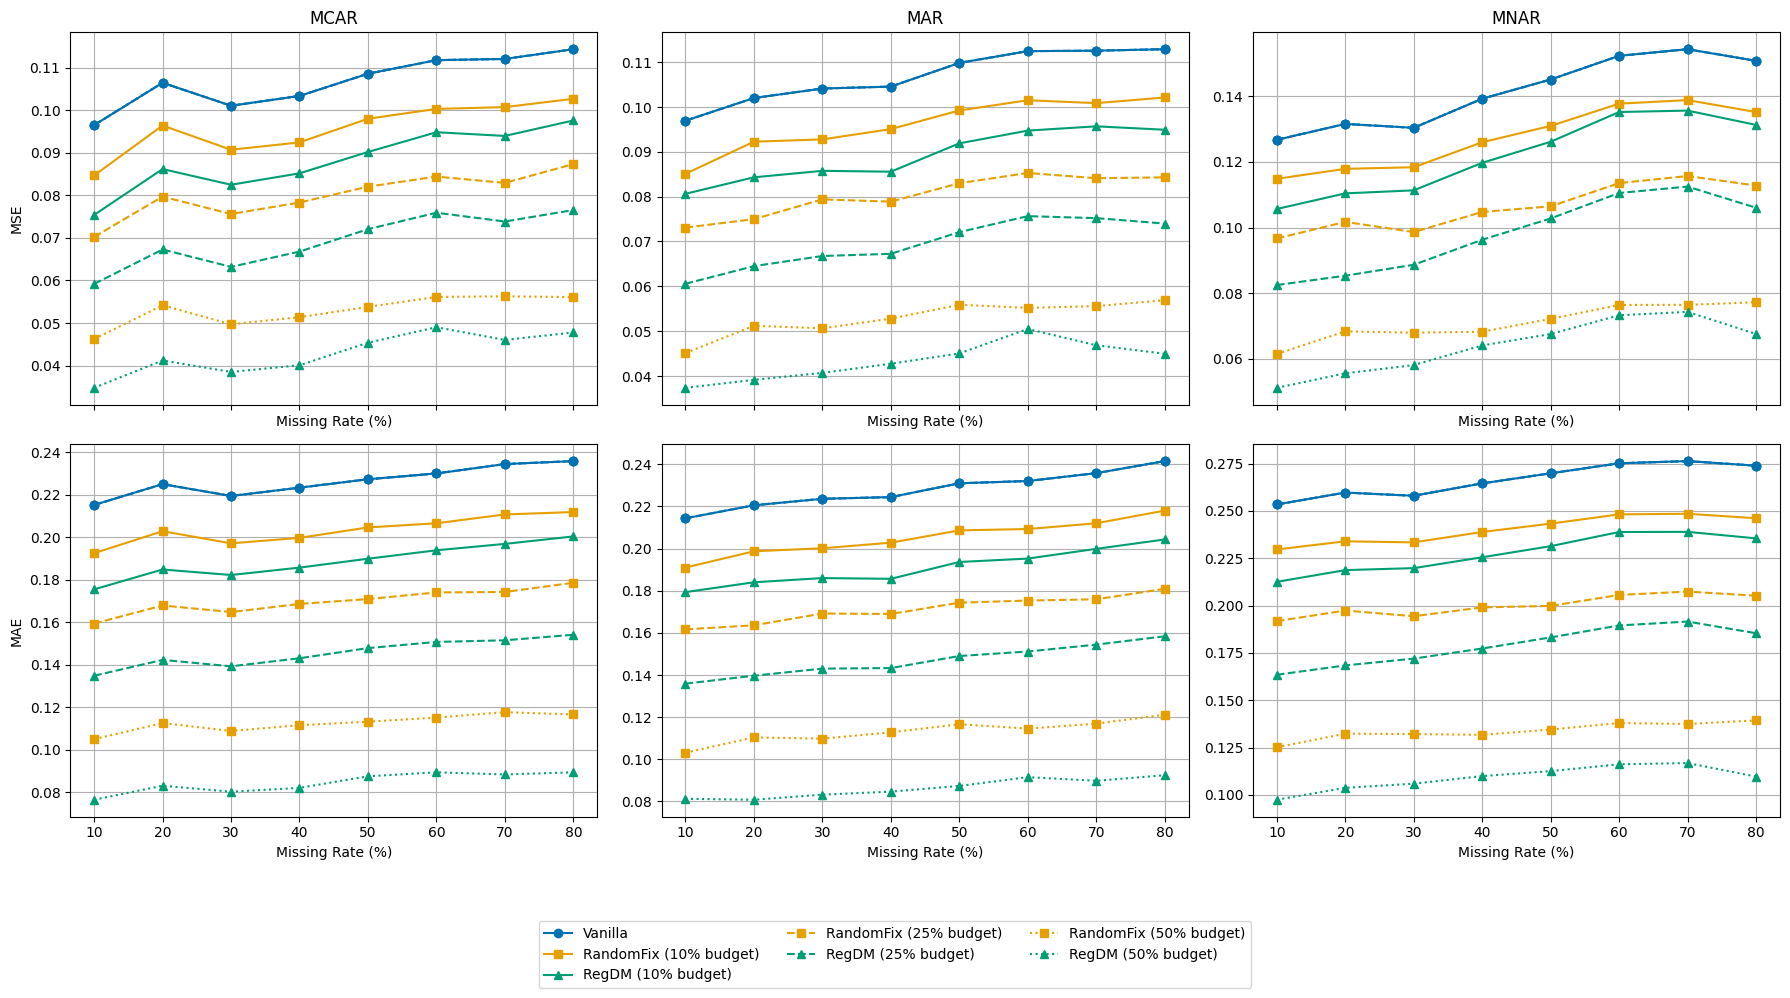

In [22]:
import matplotlib.pyplot as plt

# === Data Setup (replace these with your real data) ===
# Each pattern result should follow this format:
# results_*[metric]["budget_fraction"]["method"] = list of values
pattern_data = {
    "MCAR": results_mcar,
    "MAR": results_mar,
    "MNAR": results_mnar
}

missing_patterns = ["MCAR", "MAR", "MNAR"]
budgets = [0.1, 0.25, 0.5]
methods = ["Vanilla", "RandomFix", "RegDM"]
missing_rates = [10, 20, 30, 40, 50, 60, 70, 80]  # Adjust as needed

# === Style Settings ===
line_styles = {0.1: '-', 0.25: '--', 0.5: ':'}
markers = {"Vanilla": 'o', "RandomFix": 's', "RegDM": '^'}
colors = {"Vanilla": '#0072B2', "RandomFix": '#E69F00', "RegDM": '#009E73'}  # colorblind-friendly

# === Optional: std values for error bands ===
# Format: std_data[pattern][metric][budget][method] = list of stds
# Set to None if not using
std_data = None  # or load your std_data dictionary here

# === Plotting ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

metrics = ["MSE", "MAE"]

vanilla_labeled = False

for row_idx, metric in enumerate(metrics):
    for col_idx, pattern in enumerate(missing_patterns):
        ax = axes[row_idx, col_idx]
    
        results = pattern_data[pattern]

        for budget in budgets:
            for method in methods:
                plot_method = "OT_Fix" if method == "RegDM" else method
                values = results[metric][budget][plot_method]

                if len(values) != len(missing_rates):
                    print(f"⚠️ Skipped: {pattern}, {metric}, {method}, budget {budget}")
                    continue

                # Plot mean line
                if method == "Vanilla":
                    label = "Vanilla" if not vanilla_labeled else None
                    vanilla_labeled = True
                else:
                    label = f"{method} ({int(budget * 100)}% budget)"

                

                ax.plot(
                    missing_rates,
                    values,
                    linestyle=line_styles[budget],
                    marker=markers[method],
                    color=colors[method],
                    label=label
                )


                # Optional: Error bands
                if std_data:
                    std_vals = std_data[pattern][metric][budget][method]
                    if len(std_vals) == len(values):
                        lower = [v - s for v, s in zip(values, std_vals)]
                        upper = [v + s for v, s in zip(values, std_vals)]
                        ax.fill_between(missing_rates, lower, upper, color=colors[method], alpha=0.2)

        if row_idx == 0:
            ax.set_title(pattern)
        if col_idx == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("Missing Rate (%)")
        ax.grid(True)

# === Shared Legend ===
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', bbox_to_anchor=(0.5, -0.05))

# === Main Title & Layout ===

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German.pdf", bbox_inches='tight')

plt.show()


### Optimization

In [23]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

ActiveOTOpt - one run- internal sd with dropout noise 0.005, snapshot 10

In [24]:
results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=1000, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=1000, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=1000,
        batchsize=128,
        dropout_noise_scale=0.005  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===



Plotting results...


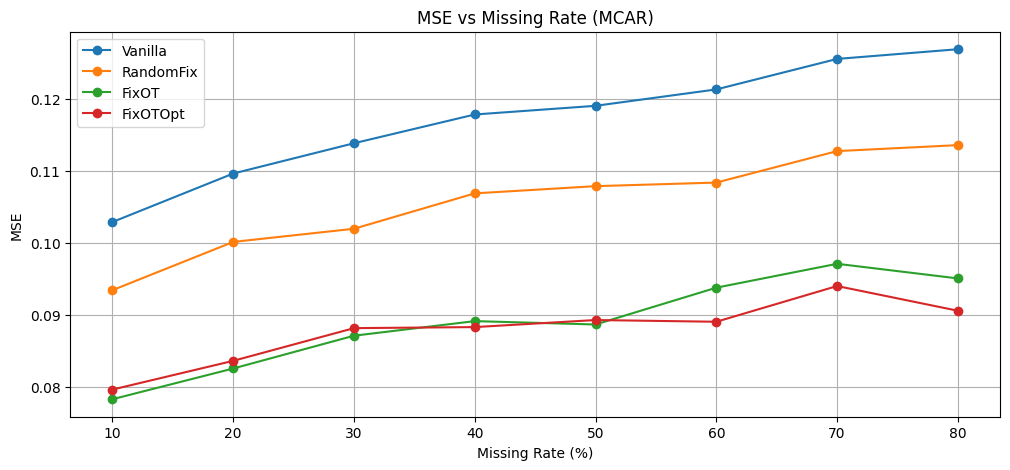

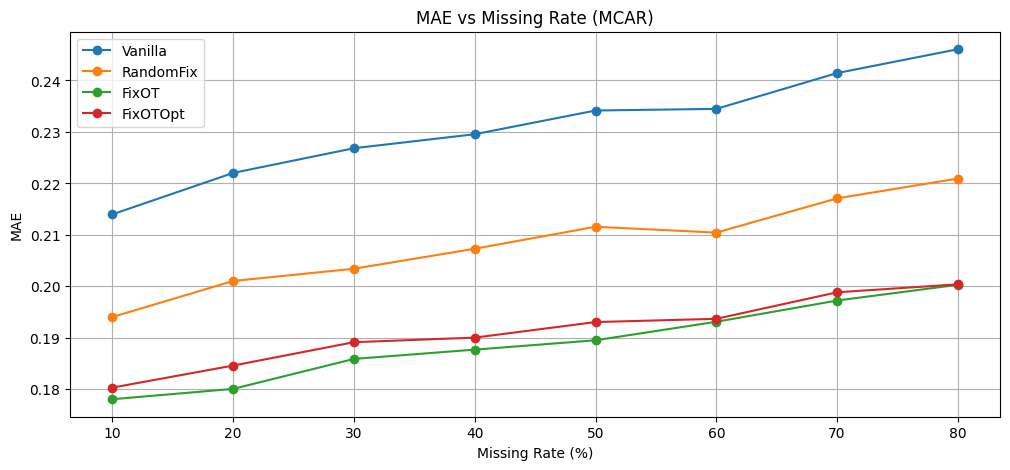

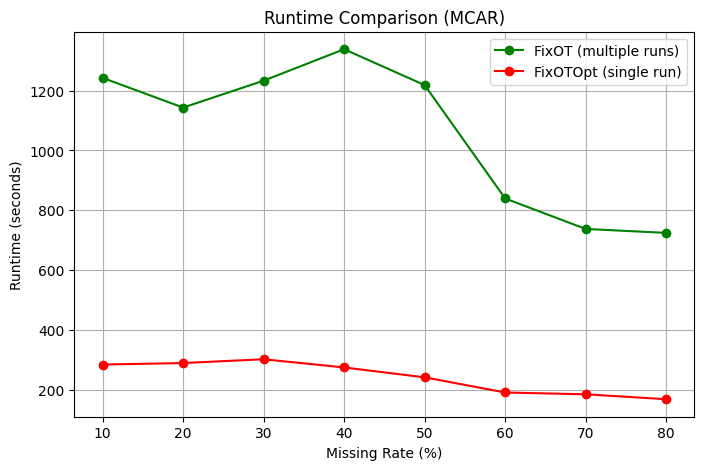

In [25]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR)")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR)")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8, 5))

# FixOT - default color
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o', color = 'green')

# FixOTOpt - set to red
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o', color='red')

plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR)")
plt.legend()
plt.grid(True)
plt.show()



ActiveOTOpt - one run- internal sd with dropout noise 0.01, snapshot 10


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


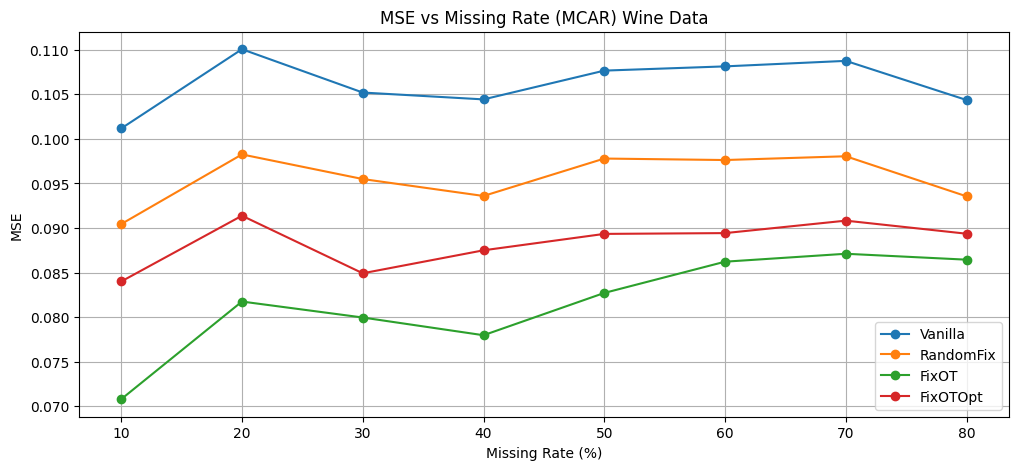

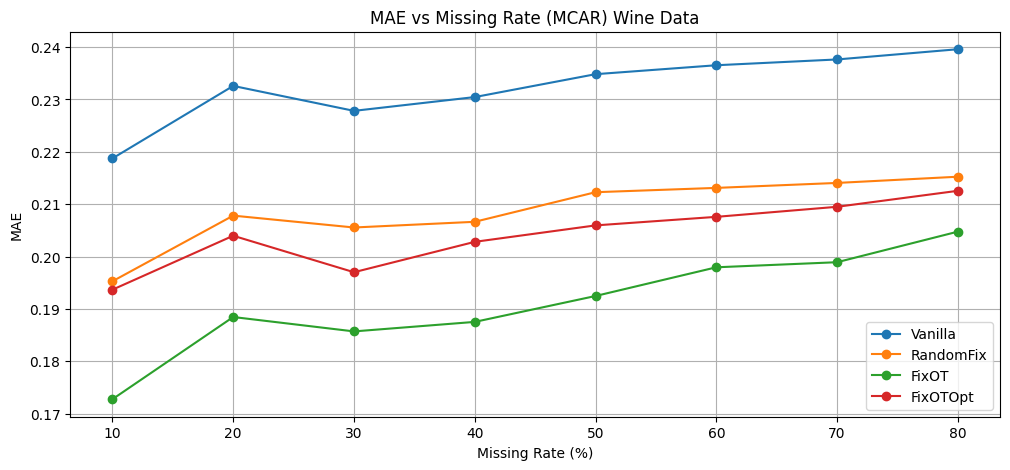

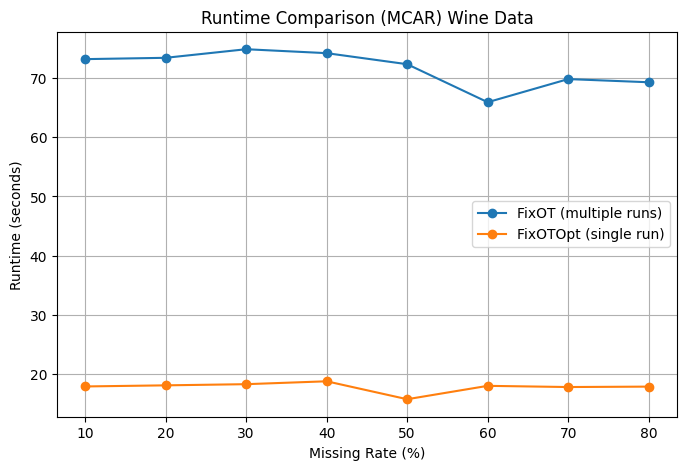

In [26]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.01  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()



ActiveOTOpt - one run- internal sd with dropout noise 0.001, snapshot 10


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


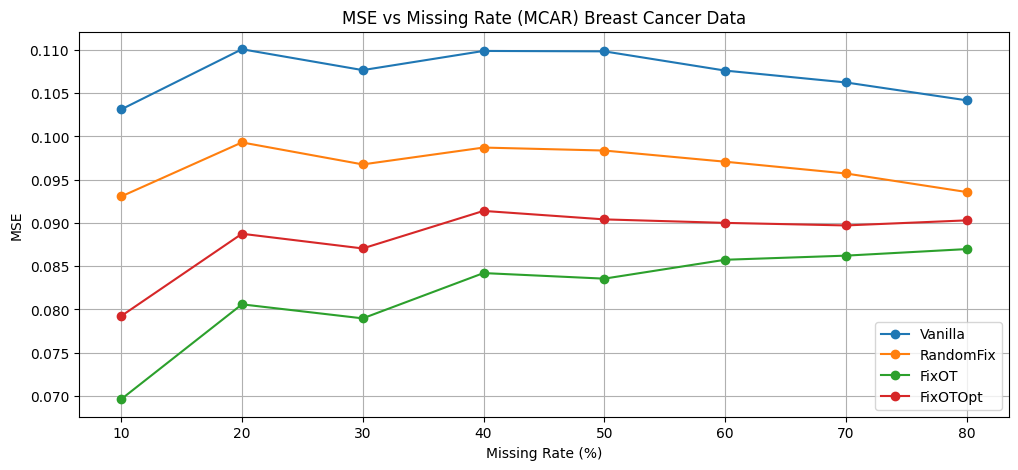

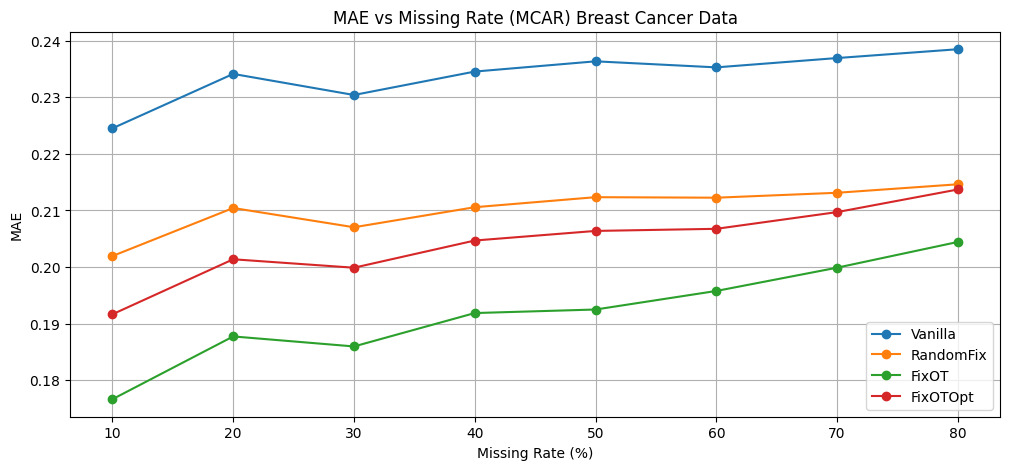

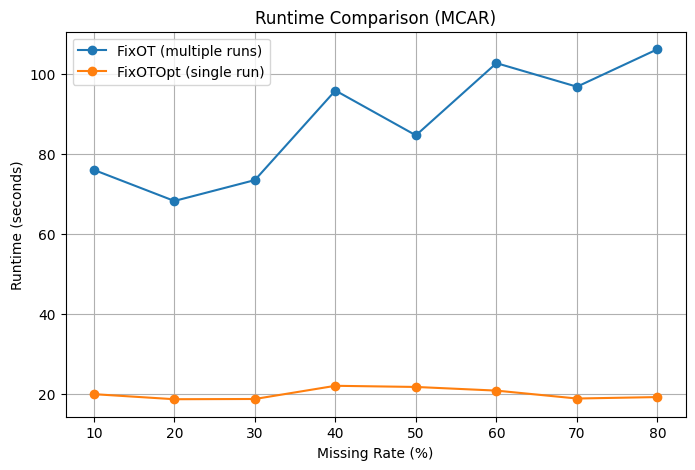

In [27]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.001  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Breast Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Breast Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR)")
plt.legend()
plt.grid(True)
plt.show()



ActiveOTOpt - one run- internal sd with dropout noise 0.0, snapshot 10


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


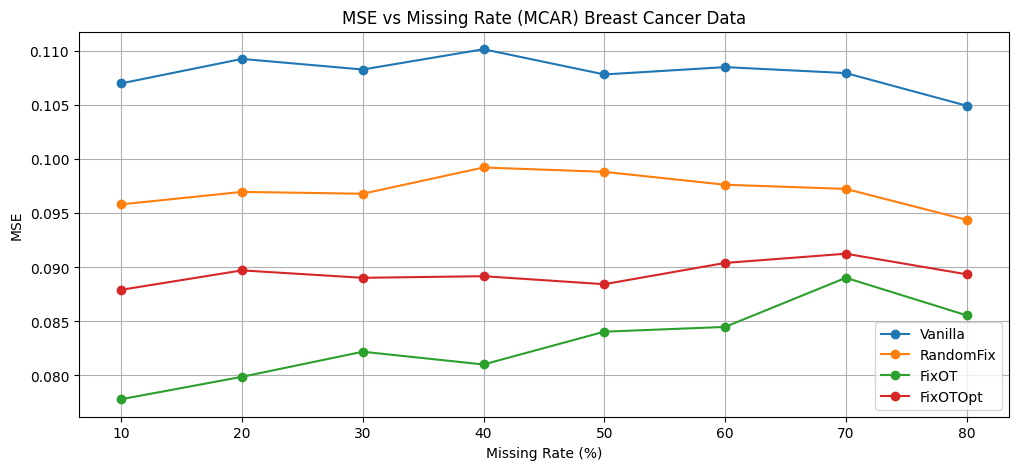

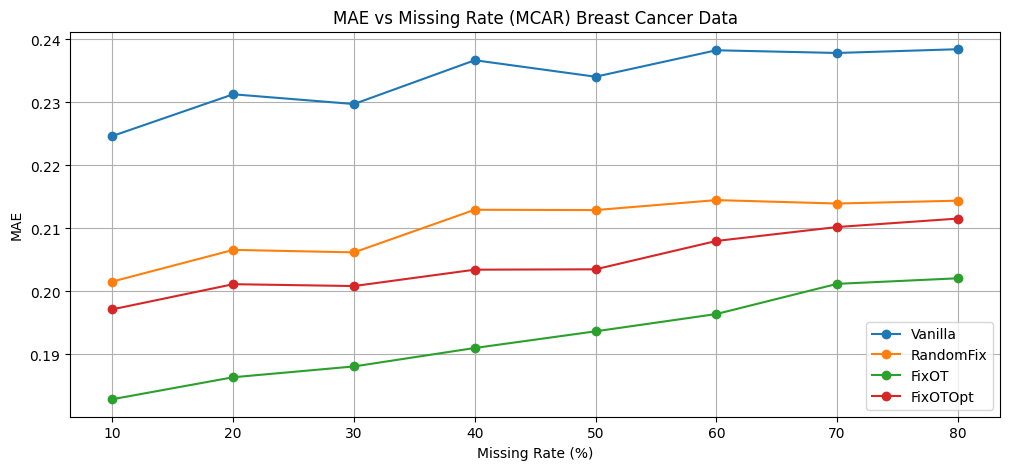

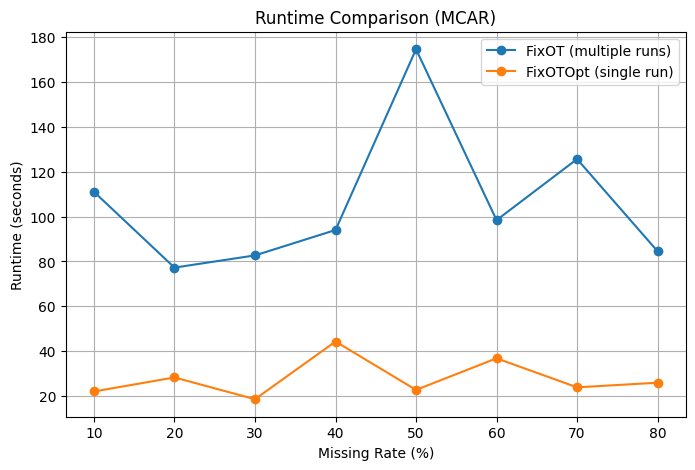

In [28]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.0 # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Breast Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Breast Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR)")
plt.legend()
plt.grid(True)
plt.show()



ActiveOTOpt - one run- internal sd with dropout noise 0.002, snapshot 10


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


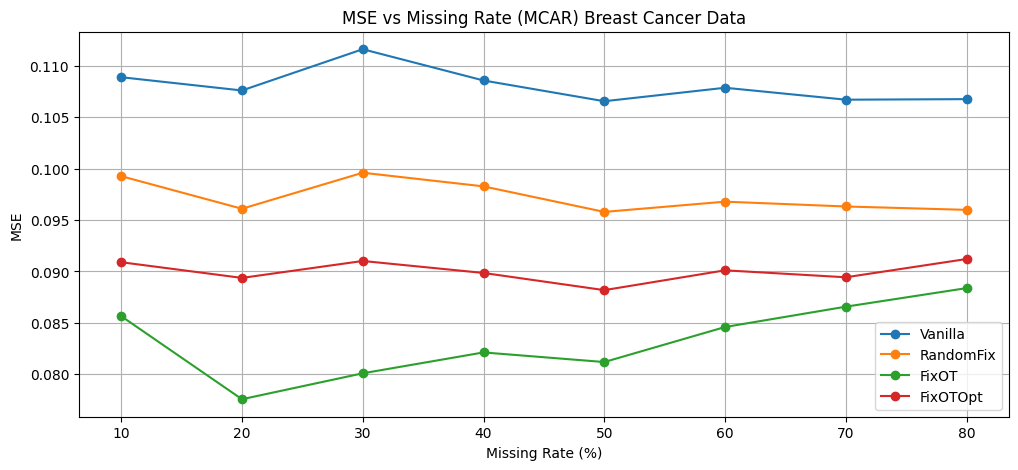

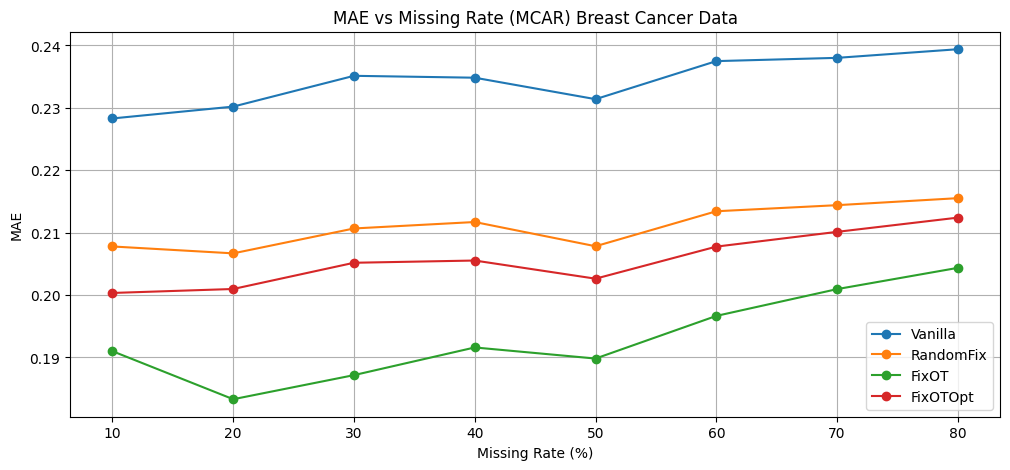

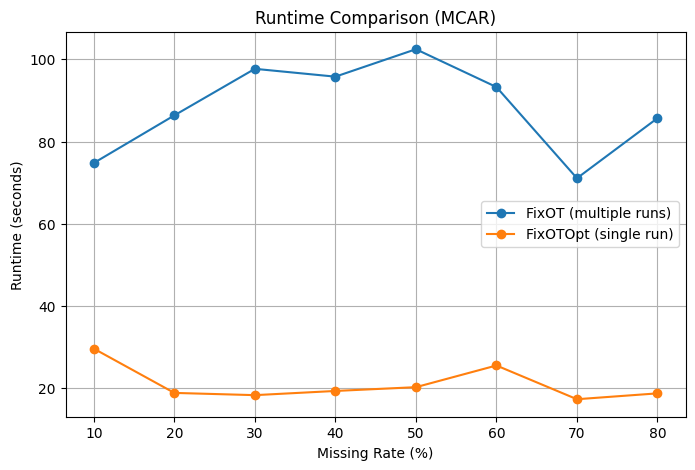

In [29]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.002  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Breast Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Breast Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR)")
plt.legend()
plt.grid(True)
plt.show()



Full Active OT with no noise, snapshot 10


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


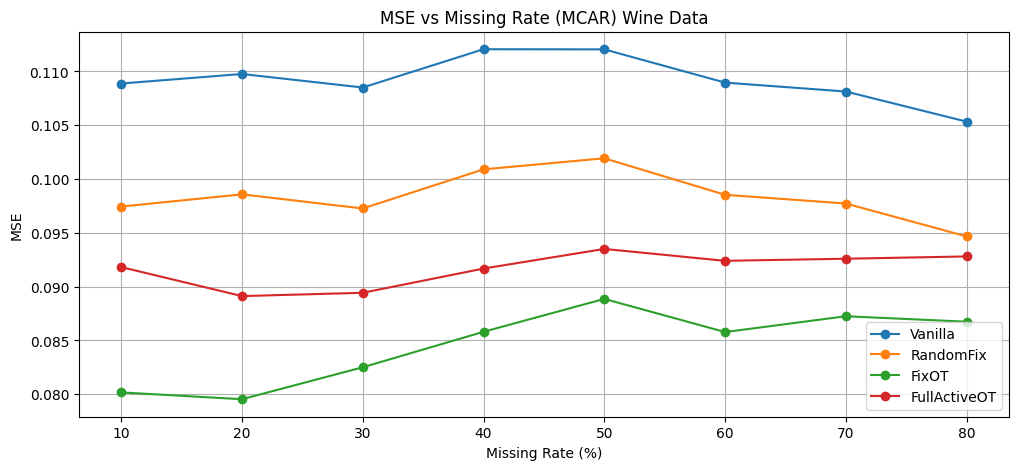

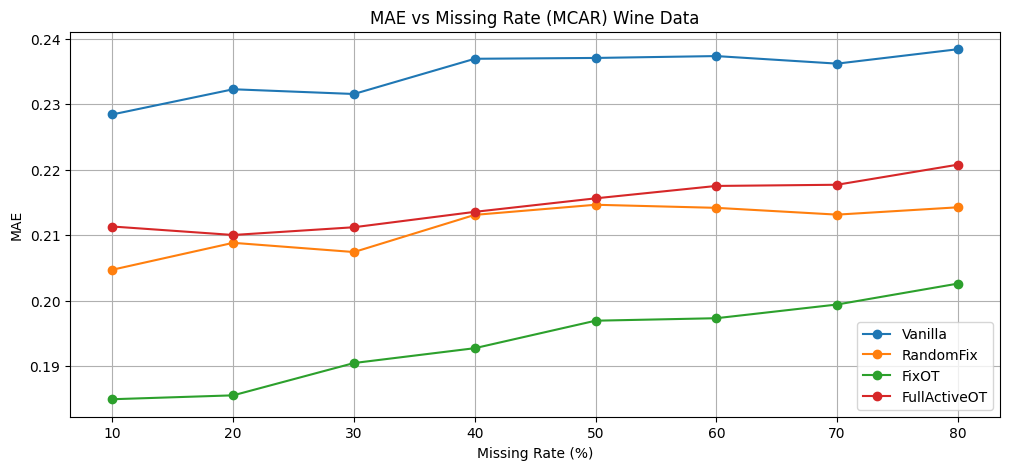

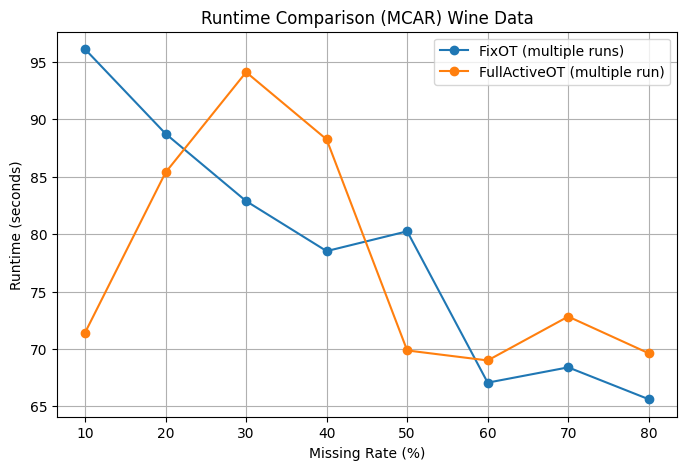

In [30]:
results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "Time": {"FixOT": [], "FullActiveOT": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # Fully ActiveOT (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()
    active_budget = int(budget / 5)
    active_imputed_runs = []
    for _ in range(4):

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

        ot_imputer = OTimputer(
        niter=100,
        batchsize=128,)
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10)

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()

        top_indices_opt = np.argsort(-std_values_opt)[:active_budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
        active_imputed_runs.append(X_activeopt_fixed)
    

    active_imputed_stack = np.stack(active_imputed_runs, axis=0)
    imputed_mean_fully_active = np.nanmean(active_imputed_stack, axis=0)
    imputed_std_fully_active = np.nanstd(active_imputed_stack, axis=0)

    std_values_fully_active = imputed_std_fully_active[missing_mask.values]
    top_indices_fully = np.argsort(-std_values_fully_active)[:active_budget]
    fully_active_selected_positions = missing_positions[top_indices_fully]

    X_fully_active_fixed = imputed_mean_fully_active.copy()

    for row_idx, col_idx in fully_active_selected_positions:
         X_fully_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
    

    activefully_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values],  X_fully_active_fixed[missing_mask.values])
    activefully_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values],  X_fully_active_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FullActiveOT"].append(activefully_fix_mse )
    results_mcar_opt["MAE"]["FullActiveOT"].append(activefully_fix_mae)
    results_mcar_opt["Time"]["FullActiveOT"].append(activeotopt_time)


# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FullActiveOT"], label="FullActiveOT (multiple run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()




Full Active OT with no noise, snapshot 5


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


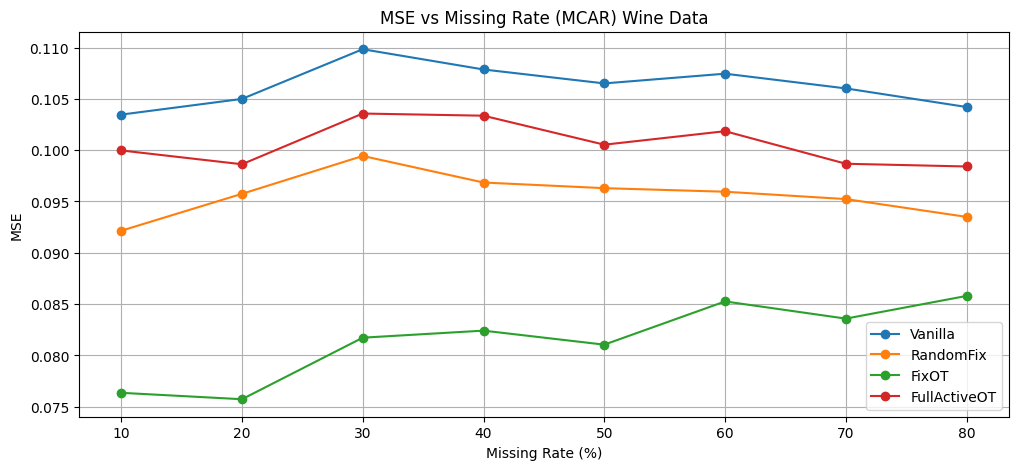

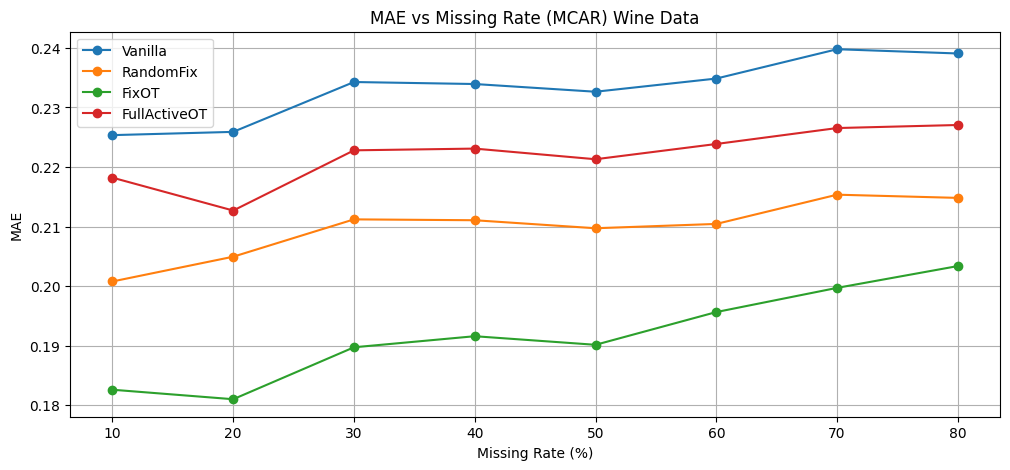

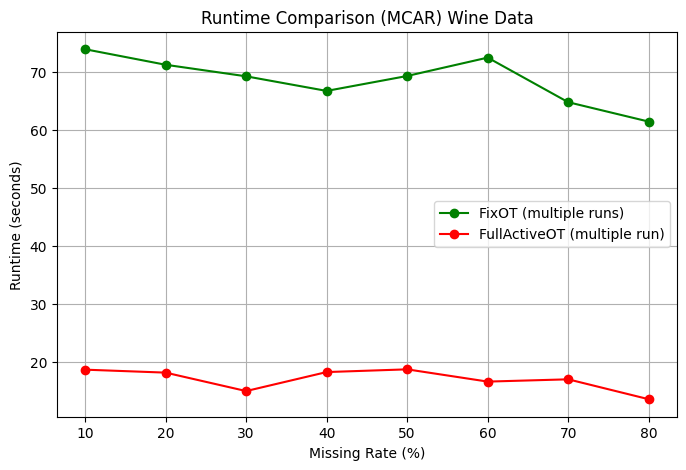

In [31]:
results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "Time": {"FixOT": [], "FullActiveOT": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # Fully ActiveOT (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()
    active_budget = int(budget / 5)
    active_imputed_runs = []
    for _ in range(1):

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

        ot_imputer = OTimputer(
        niter=100,
        batchsize=128,)
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5)

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()

        top_indices_opt = np.argsort(-std_values_opt)[:active_budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
        active_imputed_runs.append(X_activeopt_fixed)
    

    active_imputed_stack = np.stack(active_imputed_runs, axis=0)
    imputed_mean_fully_active = np.nanmean(active_imputed_stack, axis=0)
    imputed_std_fully_active = np.nanstd(active_imputed_stack, axis=0)

    std_values_fully_active = imputed_std_fully_active[missing_mask.values]
    top_indices_fully = np.argsort(-std_values_fully_active)[:active_budget]
    fully_active_selected_positions = missing_positions[top_indices_fully]

    X_fully_active_fixed = imputed_mean_fully_active.copy()

    for row_idx, col_idx in fully_active_selected_positions:
         X_fully_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
    

    activefully_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values],  X_fully_active_fixed[missing_mask.values])
    activefully_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values],  X_fully_active_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FullActiveOT"].append(activefully_fix_mse )
    results_mcar_opt["MAE"]["FullActiveOT"].append(activefully_fix_mae)
    results_mcar_opt["Time"]["FullActiveOT"].append(activeotopt_time)


# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mcar_opt["Time"]["FullActiveOT"], label="FullActiveOT (multiple run)", marker='o',color='red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()




Full Active OT with noise, snapshot= 10, noise= 0.005


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


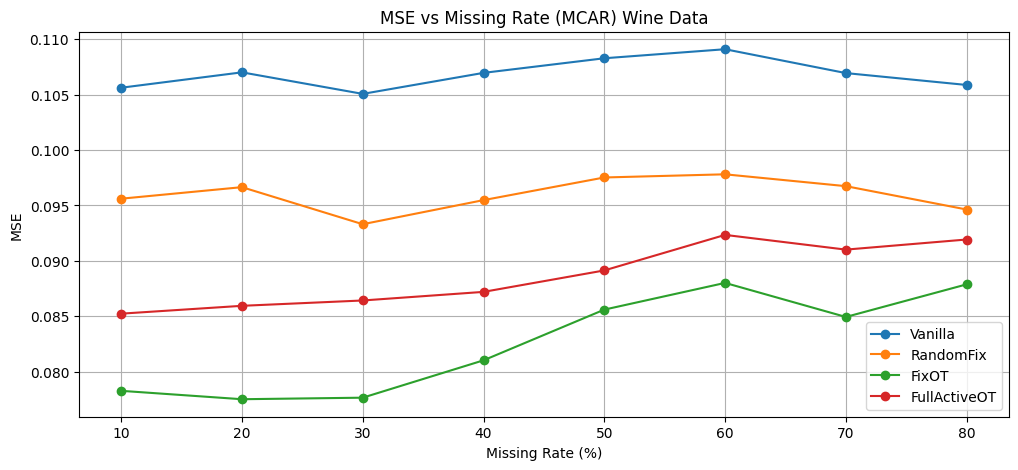

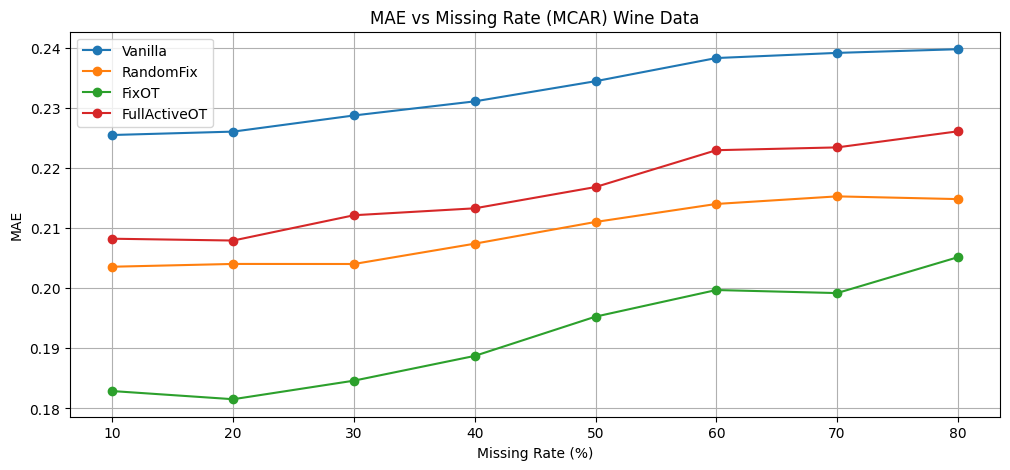

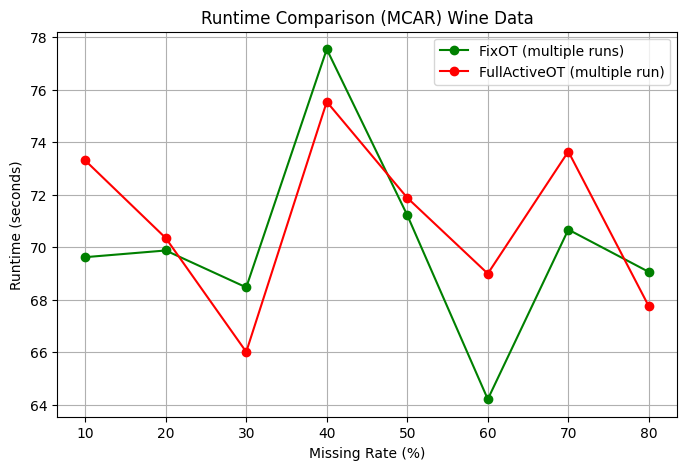

In [32]:
results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "Time": {"FixOT": [], "FullActiveOT": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # Fully ActiveOT (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()
    active_budget = int(budget / 5)
    active_imputed_runs = []
    for _ in range(4):

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

        ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.005)
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10)

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()

        top_indices_opt = np.argsort(-std_values_opt)[:active_budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
        active_imputed_runs.append(X_activeopt_fixed)
    

    active_imputed_stack = np.stack(active_imputed_runs, axis=0)
    imputed_mean_fully_active = np.nanmean(active_imputed_stack, axis=0)
    imputed_std_fully_active = np.nanstd(active_imputed_stack, axis=0)

    std_values_fully_active = imputed_std_fully_active[missing_mask.values]
    top_indices_fully = np.argsort(-std_values_fully_active)[:active_budget]
    fully_active_selected_positions = missing_positions[top_indices_fully]

    X_fully_active_fixed = imputed_mean_fully_active.copy()

    for row_idx, col_idx in fully_active_selected_positions:
         X_fully_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
    

    activefully_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values],  X_fully_active_fixed[missing_mask.values])
    activefully_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values],  X_fully_active_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FullActiveOT"].append(activefully_fix_mse )
    results_mcar_opt["MAE"]["FullActiveOT"].append(activefully_fix_mae)
    results_mcar_opt["Time"]["FullActiveOT"].append(activeotopt_time)


# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mcar_opt["Time"]["FullActiveOT"], label="FullActiveOT (multiple run)", marker='o',color='red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()




ActiveOTOpt - one run- internal sd with no noise, snapshot 3


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


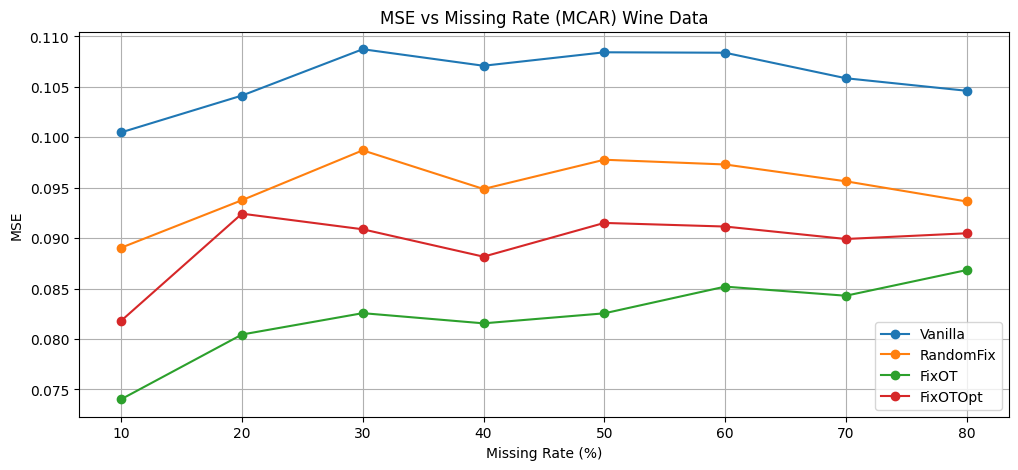

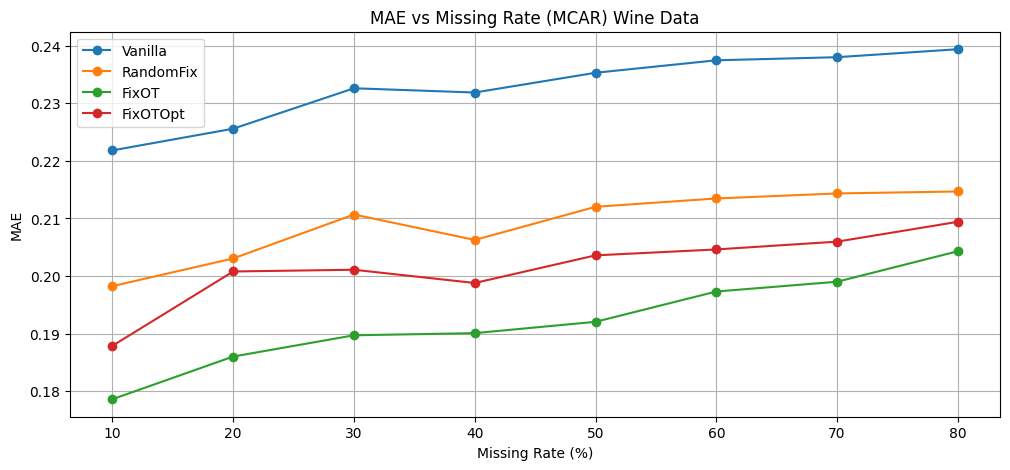

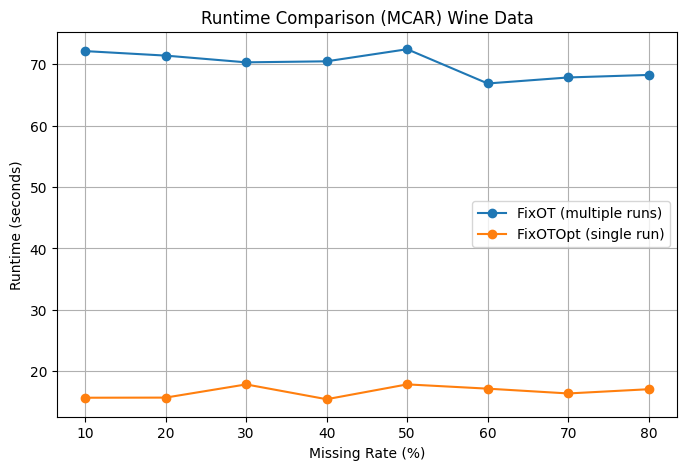

In [33]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(
        niter=100,
        batchsize=128,
         # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 3
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()



Full Active OT with no noise


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


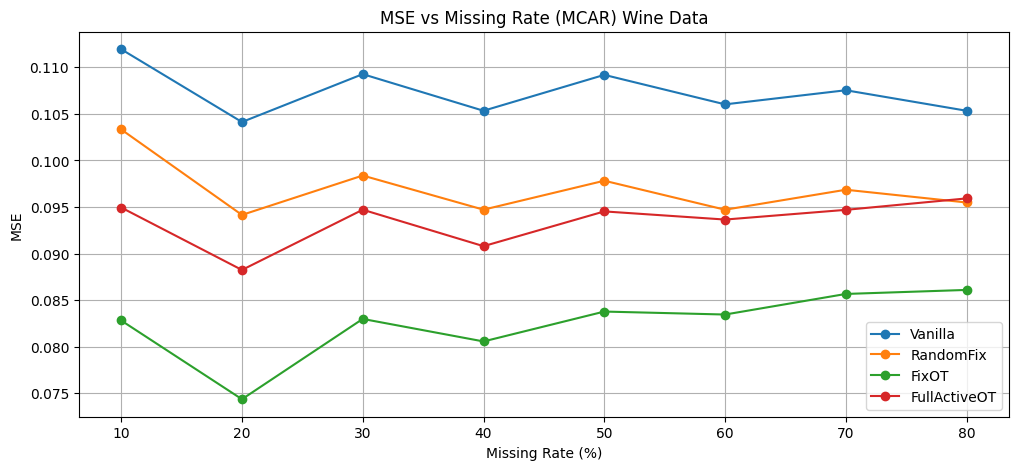

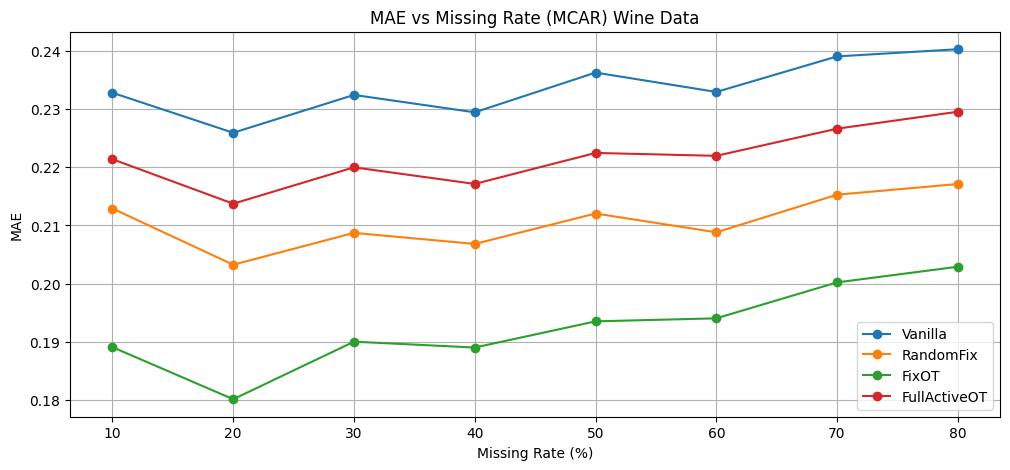

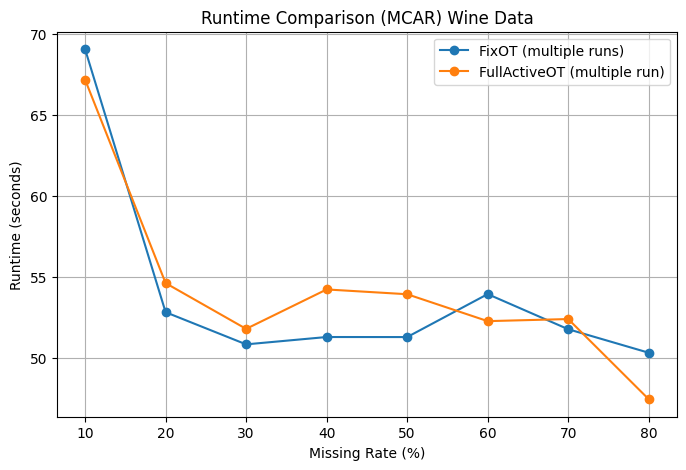

In [34]:
results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "Time": {"FixOT": [], "FullActiveOT": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # Fully ActiveOT (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()
    active_budget = int(budget / 4)
    active_imputed_runs = []
    for _ in range(4):

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

        ot_imputer = OTimputer(
        niter=100,
        batchsize=128,)
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5)

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()

        top_indices_opt = np.argsort(-std_values_opt)[:active_budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
        active_imputed_runs.append(X_activeopt_fixed)
    

    active_imputed_stack = np.stack(active_imputed_runs, axis=0)
    imputed_mean_fully_active = np.nanmean(active_imputed_stack, axis=0)
    imputed_std_fully_active = np.nanstd(active_imputed_stack, axis=0)

    
    

    activefully_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values],   imputed_mean_fully_active[missing_mask.values])
    activefully_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values],   imputed_mean_fully_active[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FullActiveOT"].append(activefully_fix_mse )
    results_mcar_opt["MAE"]["FullActiveOT"].append(activefully_fix_mae)
    results_mcar_opt["Time"]["FullActiveOT"].append(activeotopt_time)


# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FullActiveOT"], label="FullActiveOT (multiple run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()




Full Active OT, no noise, two run


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


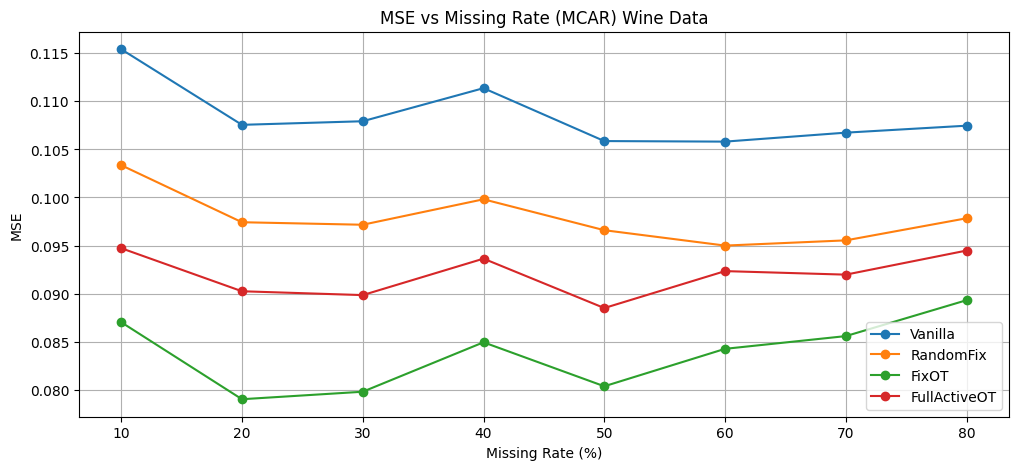

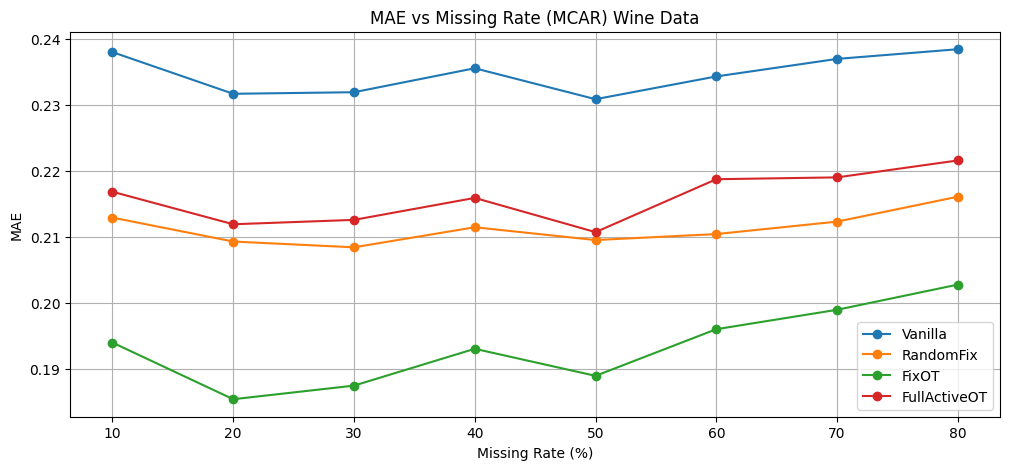

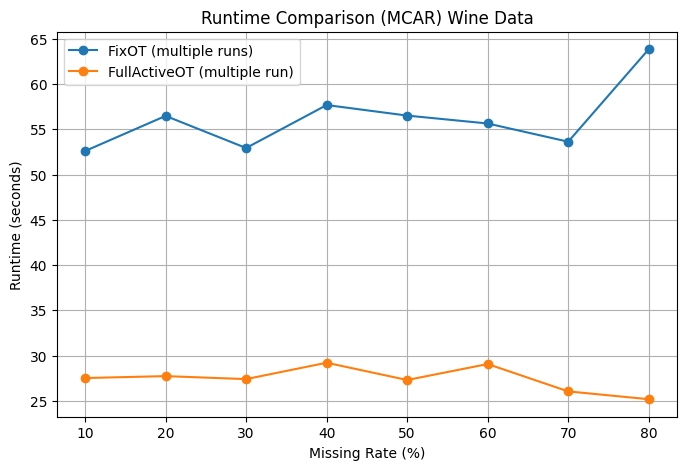

In [35]:
results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FullActiveOT": []},
    "Time": {"FixOT": [], "FullActiveOT": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # Fully ActiveOT (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()
    active_budget = int(budget / 2)
    active_imputed_runs = []
    for _ in range(2):

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

        ot_imputer = OTimputer(
        niter=100,
        batchsize=128,)
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5)

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()

        top_indices_opt = np.argsort(-std_values_opt)[:active_budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]
        active_imputed_runs.append(X_activeopt_fixed)
    

    active_imputed_stack = np.stack(active_imputed_runs, axis=0)
    imputed_mean_fully_active = np.nanmean(active_imputed_stack, axis=0)
    imputed_std_fully_active = np.nanstd(active_imputed_stack, axis=0)

    
    

    activefully_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values],   imputed_mean_fully_active[missing_mask.values])
    activefully_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values],   imputed_mean_fully_active[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FullActiveOT"].append(activefully_fix_mse )
    results_mcar_opt["MAE"]["FullActiveOT"].append(activefully_fix_mae)
    results_mcar_opt["Time"]["FullActiveOT"].append(activeotopt_time)


# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FullActiveOT"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FullActiveOT"], label="FullActiveOT (multiple run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
plt.show()





=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


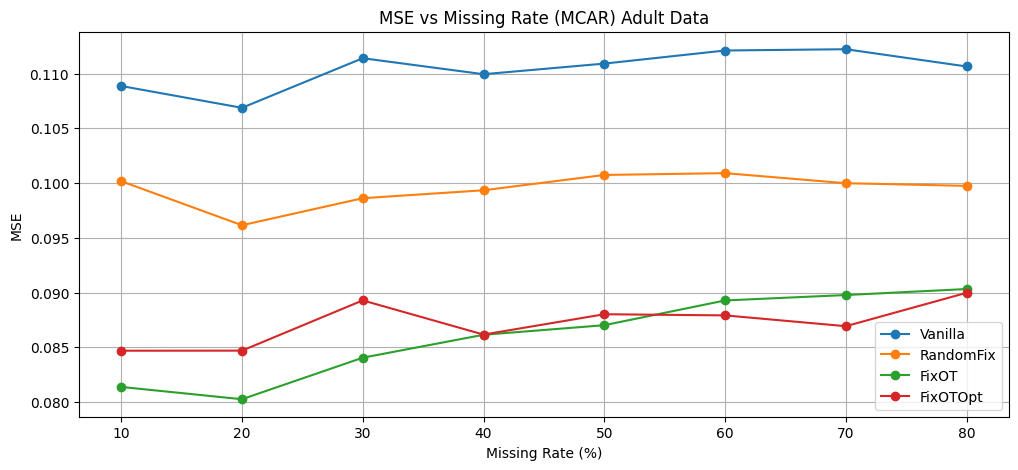

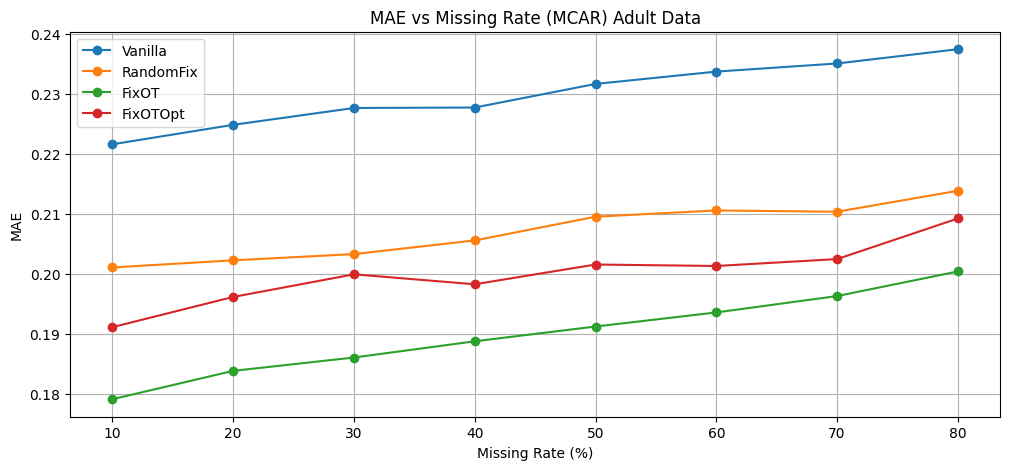

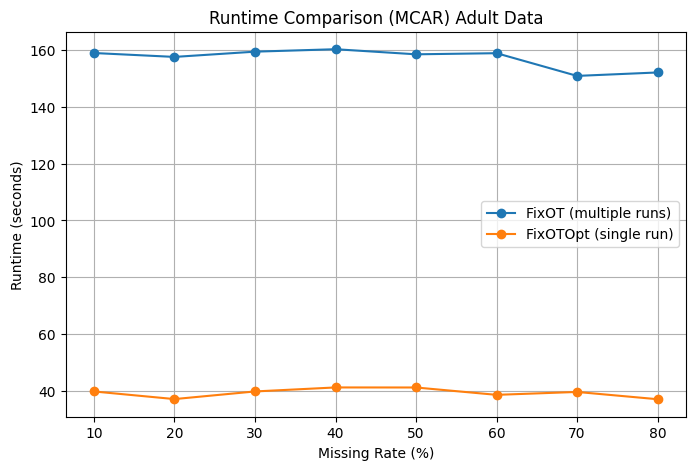

In [36]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.005
         
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=50
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()




=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


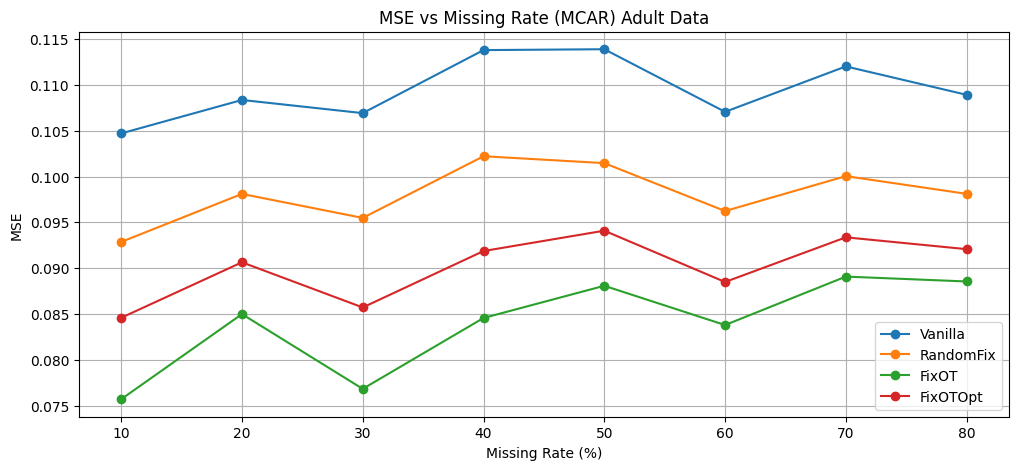

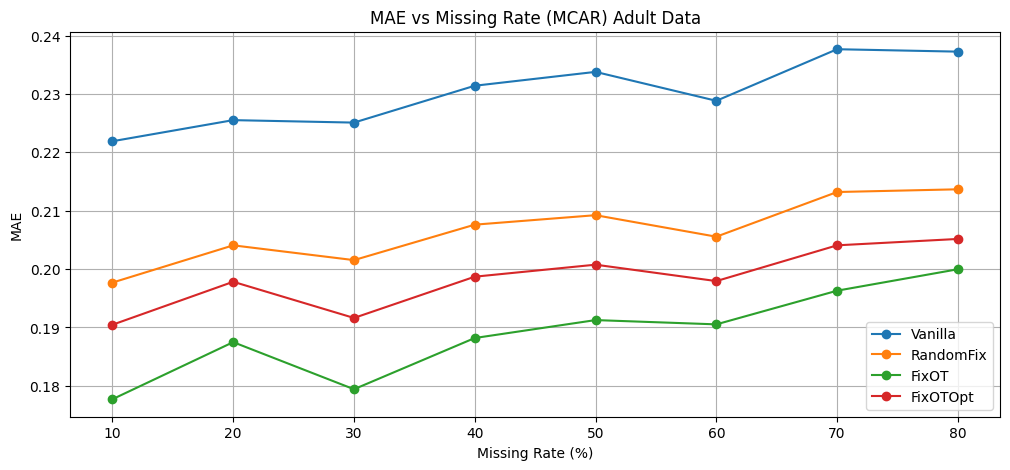

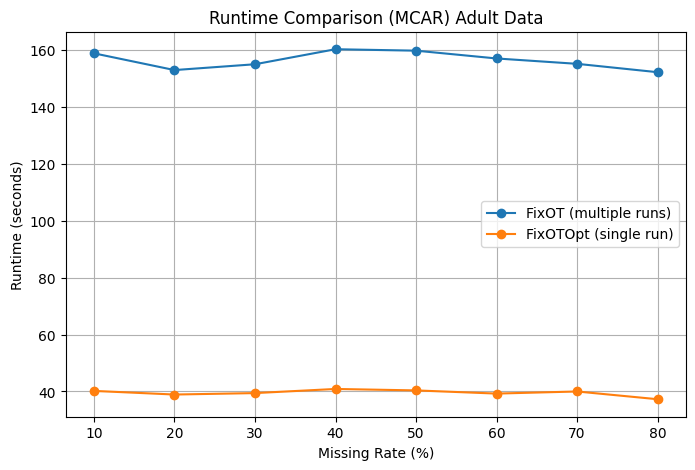

In [37]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(
        niter=300,
        batchsize=128,
         # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=50
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()




=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


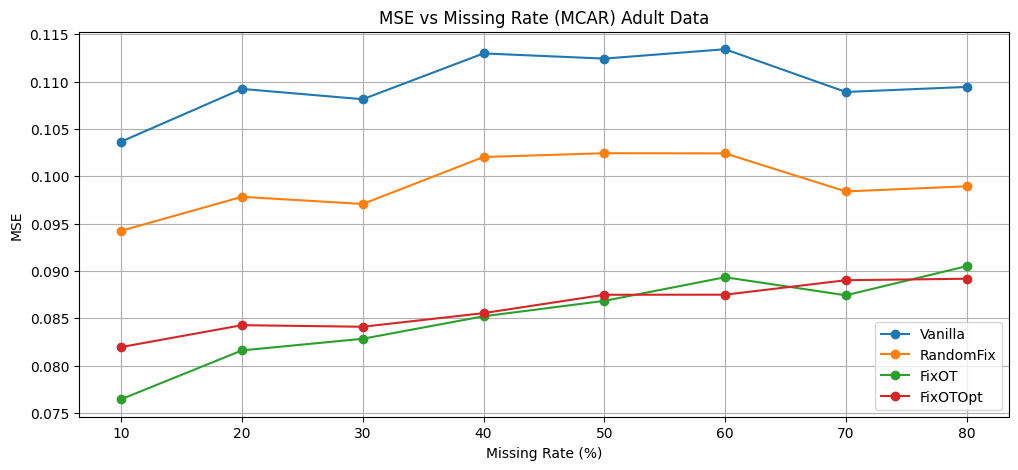

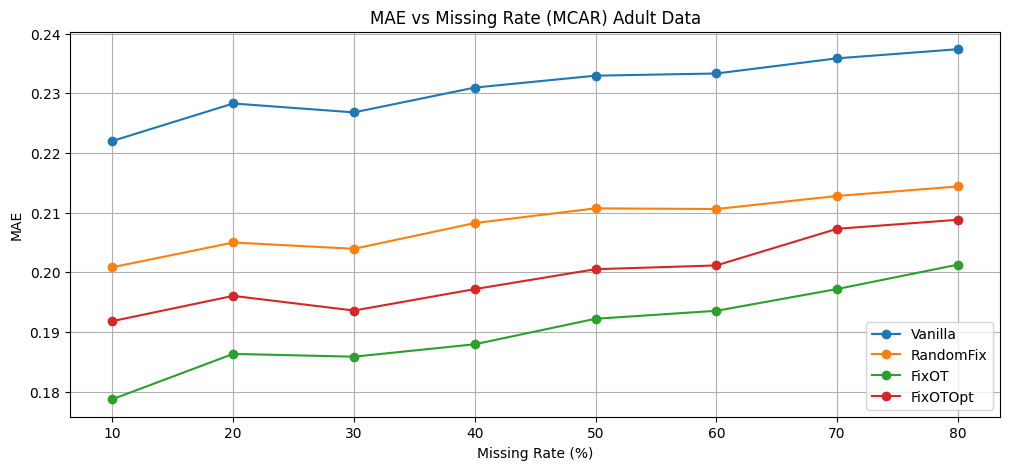

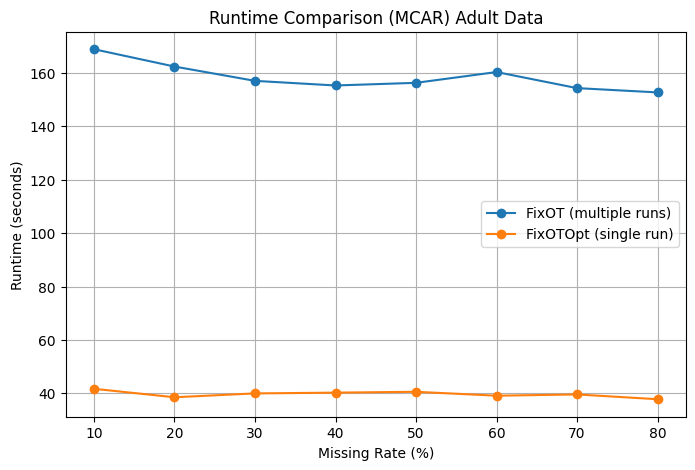

In [38]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.005
         
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=50
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()




=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


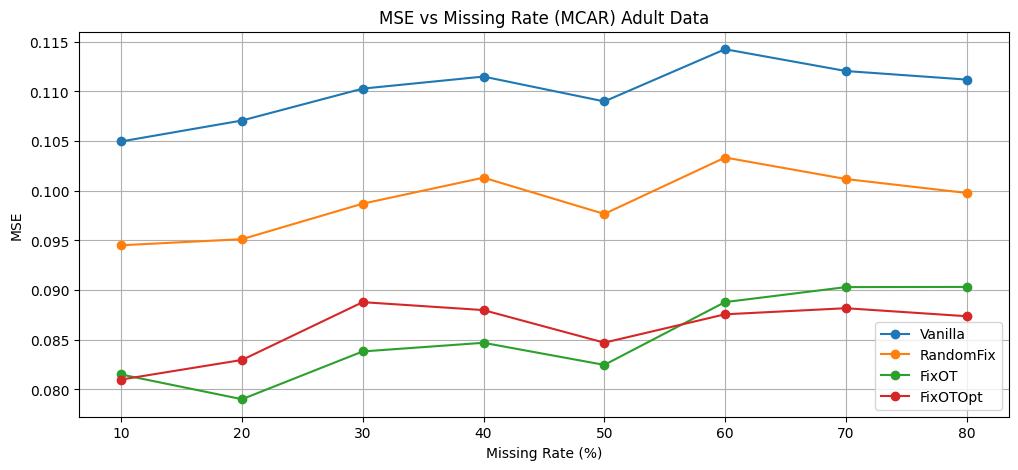

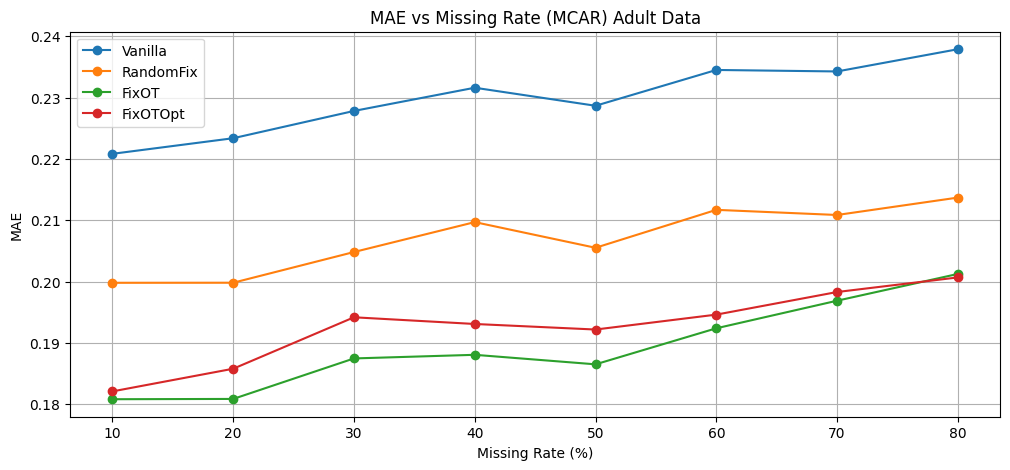

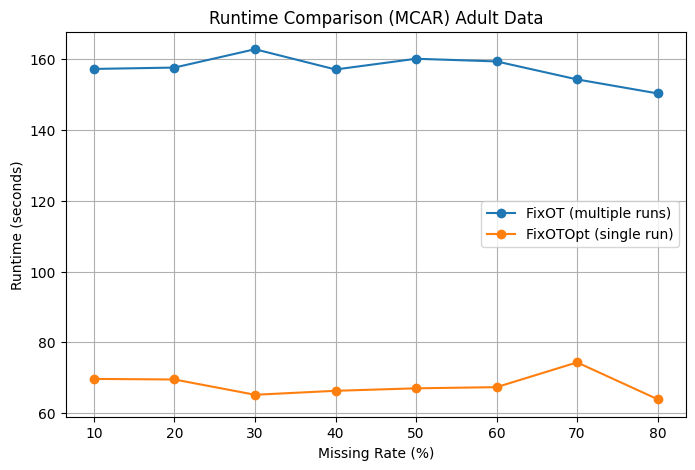

In [39]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "FixOT": [], "FixOTOpt": []},
    "Time": {"FixOT": [], "FixOTOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOT"].append(active_fix_mse)
    results_mcar_opt["MAE"]["FixOT"].append(active_fix_mae)
    results_mcar_opt["Time"]["FixOT"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=500,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=5
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["FixOTOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["FixOTOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["FixOTOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "FixOT", "FixOTOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOT"], label="FixOT (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["FixOTOpt"], label="FixOTOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
plt.show()



## Optimization

MCAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


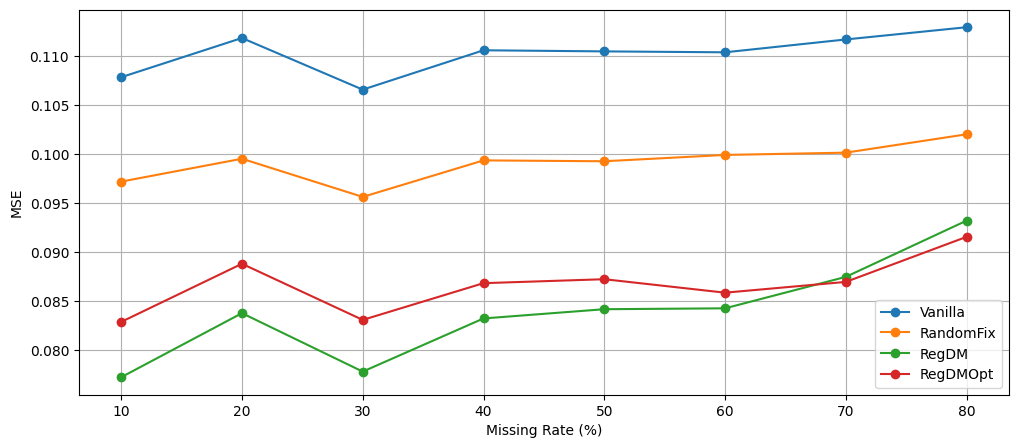

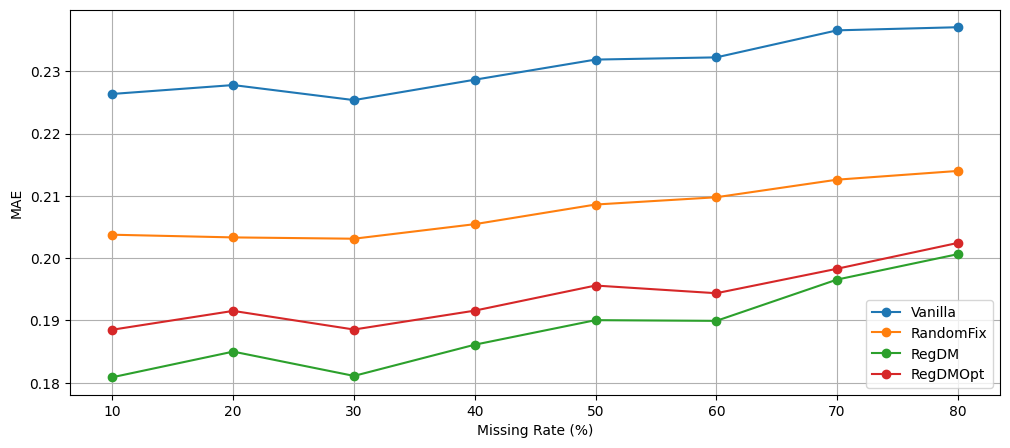

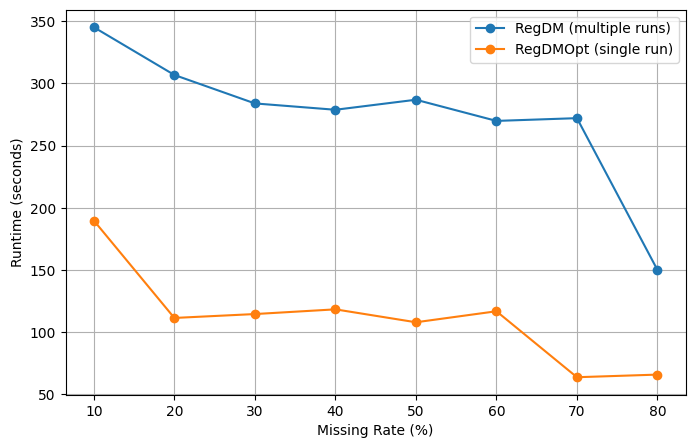

In [40]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mcar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mcar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mcar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mcar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=500,
        batchsize=128,
        dropout_noise_scale= 0.005
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["RegDMOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MCAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MCAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MCAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



MAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


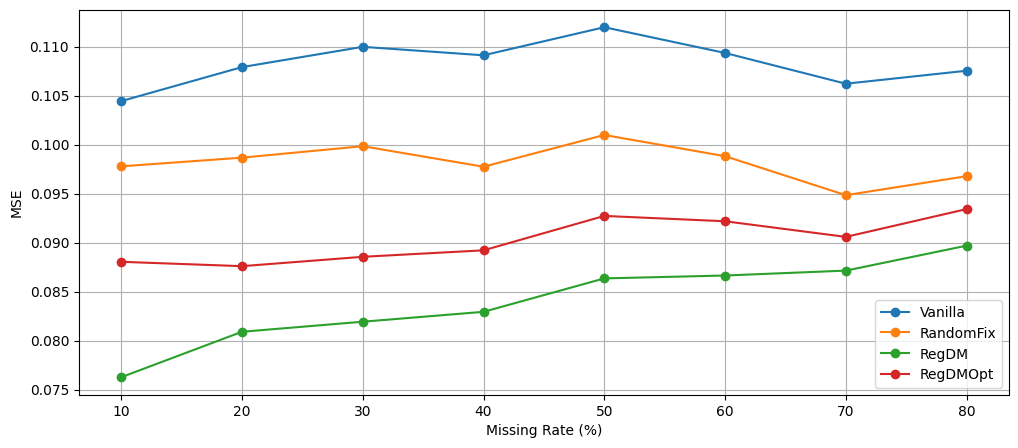

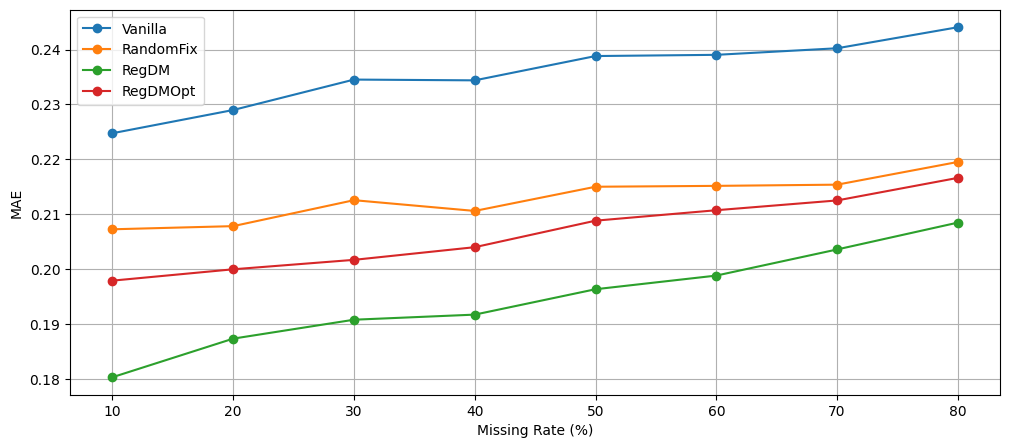

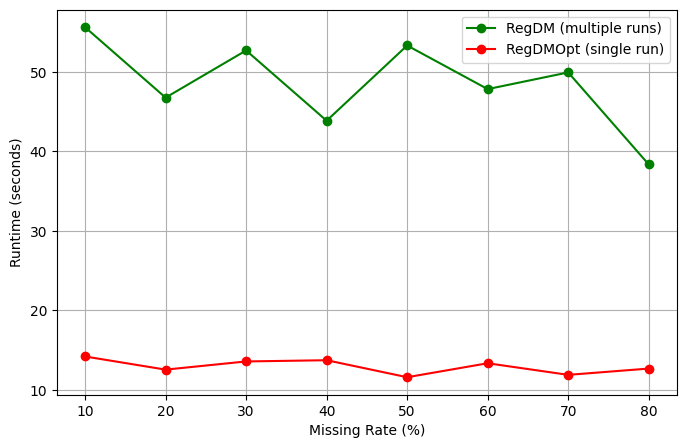

In [41]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    missing_mask = miss_mar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.005  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mar_opt["Time"]["RegDMOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()

plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o',color = 'red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



MNAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


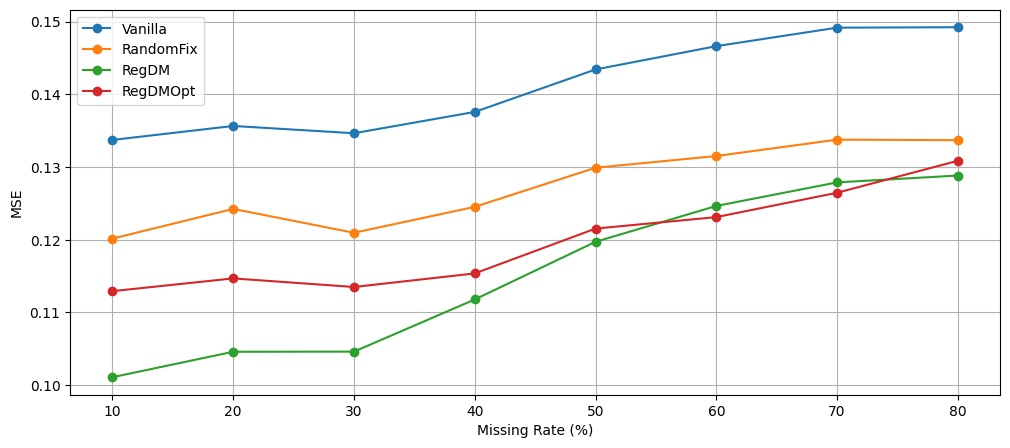

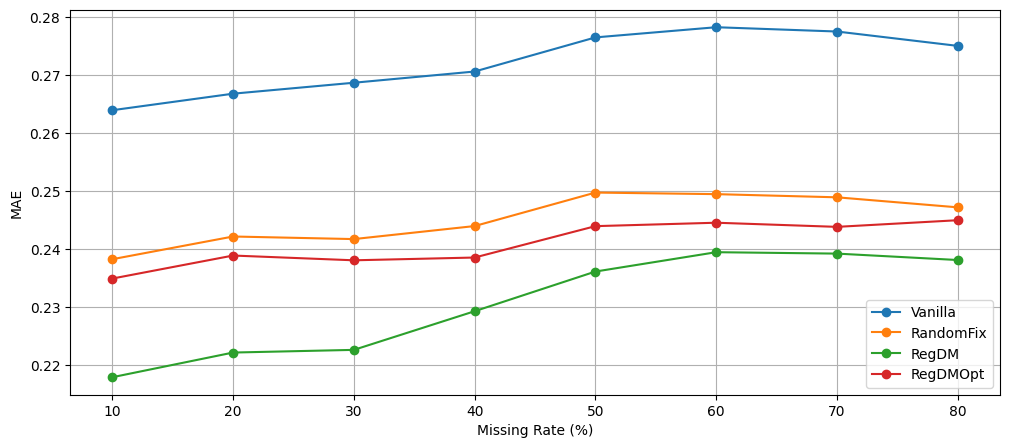

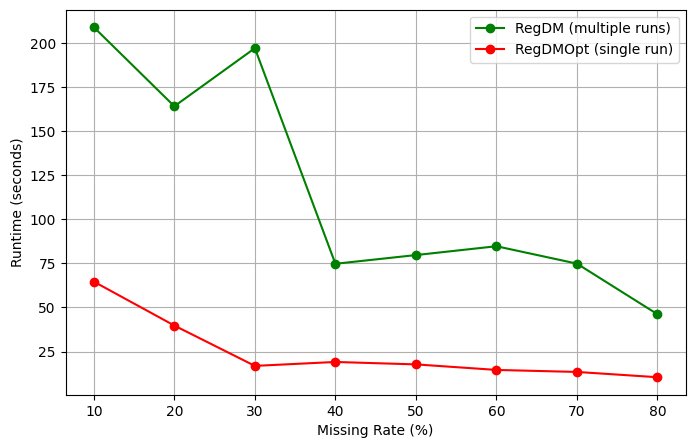

In [44]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mnar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mnar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mnar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mnar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mnar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mnar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mnar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mnar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=100,
        batchsize=128,
        dropout_noise_scale=0.005  # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mnar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mnar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mnar_opt["Time"]["RegDMOpt"].append(activeotopt_time)





# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mnar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MNAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mnar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MNAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mnar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mnar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o',color = 'red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_MNAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



## Fully Active

MCAR

In [46]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X,missing_rate=30)
mask = X_missing.isna()

results_fullyActive_mcar = []
max_k = 4
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mcar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar= pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 6000
    X_std (max value): 0.32154696294137247
    Avg Std of Queried Cells: 0.1856
    Intermediate MAE after iteration 1: 0.2010
  Final MAE: 0.2010, Time: 18.72s, Unique Queried: 600, Avg Std: 0.1856

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 6000
    X_std (max value): 0.3013919016312289
    Avg Std of Queried Cells: 0.2038
    Intermediate MAE after iteration 1: 0.2192
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero 

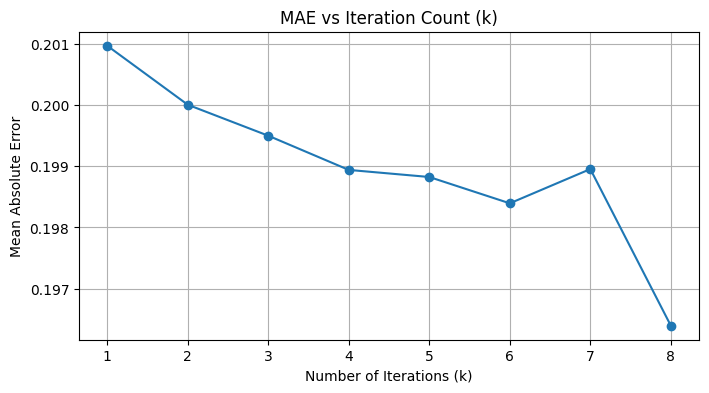

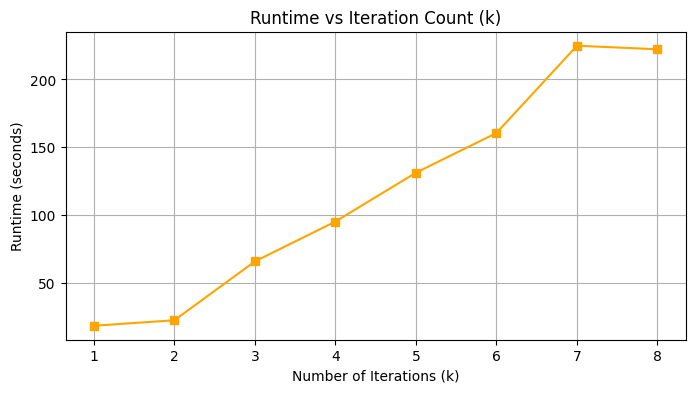

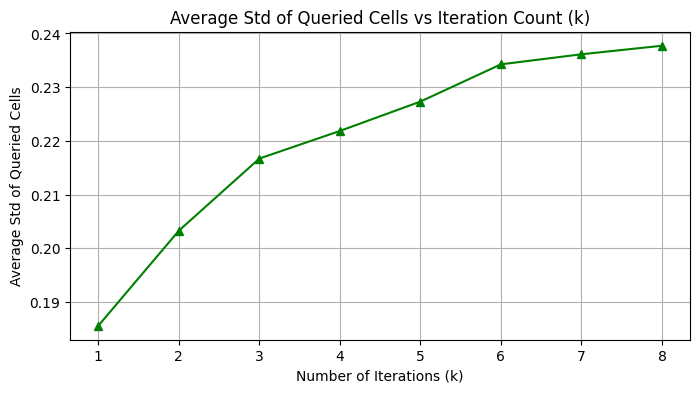

In [47]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MAR

In [48]:
generator_mar = Inject_Missing_Values()
X_missing, index_mar = generator_mar.MAR(X,missing_rate=30, dependencies = dependencies_mar)
mask = X_missing.isna()

results_fullyActive_mar = []
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 6000
    X_std (max value): 0.29162123753588604
    Avg Std of Queried Cells: 0.1842
    Intermediate MAE after iteration 1: 0.2018
  Final MAE: 0.2018, Time: 28.96s, Unique Queried: 600, Avg Std: 0.1842

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 6000
    X_std (max value): 0.328205044030305
    Avg Std of Queried Cells: 0.2043
    Intermediate MAE after iteration 1: 0.2194
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero e

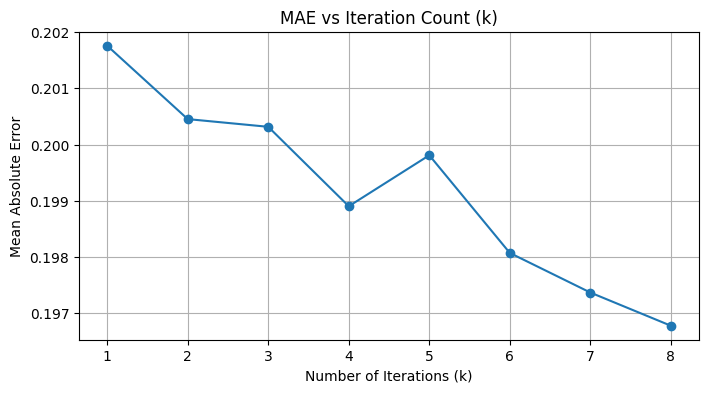

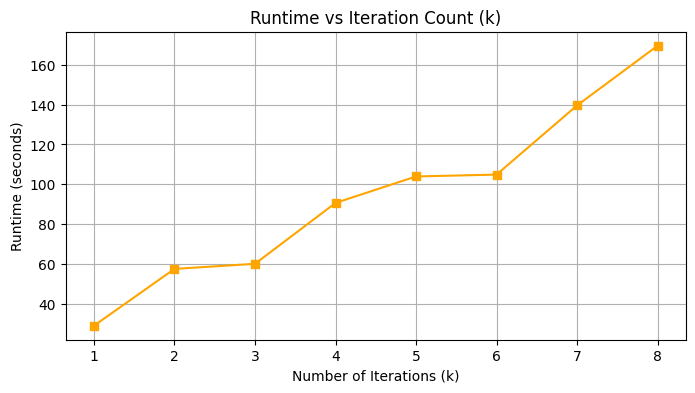

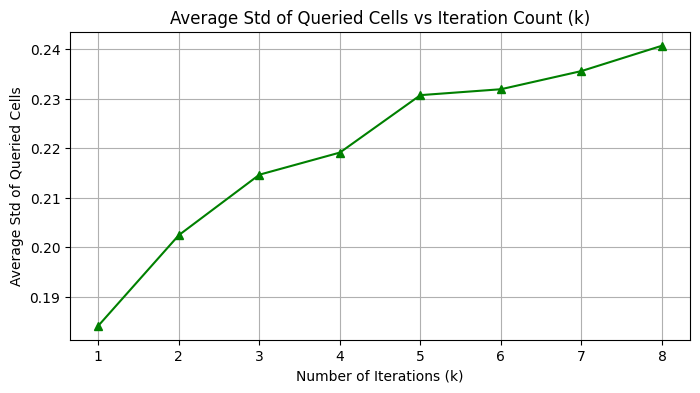

In [49]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MNAR

In [50]:
generator_mnar = Inject_Missing_Values()
X_missing, index_mnar = generator_mnar.MAR(X,missing_rate=30, dependencies = dependencies_mnar)
mask = X_missing.isna()

results_fullyActive_mnar = []
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mnar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 6000
    X_std (max value): 0.34141721246573276
    Avg Std of Queried Cells: 0.1817
    Intermediate MAE after iteration 1: 0.2374
  Final MAE: 0.2374, Time: 13.79s, Unique Queried: 600, Avg Std: 0.1817

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 6000
    X_std (max value): 0.2875992675525685
    Avg Std of Queried Cells: 0.2013
    Intermediate MAE after iteration 1: 0.2550
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero 

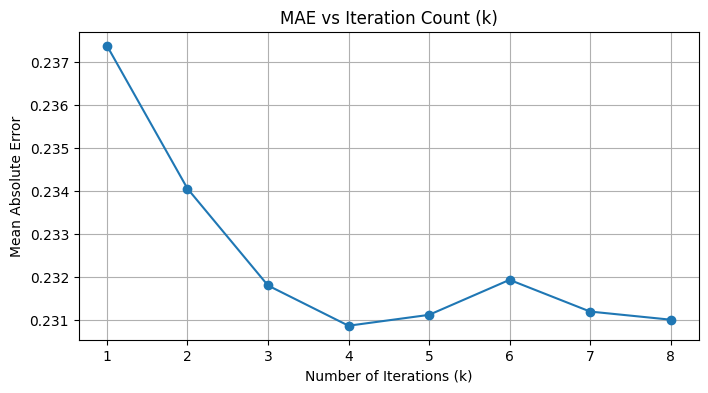

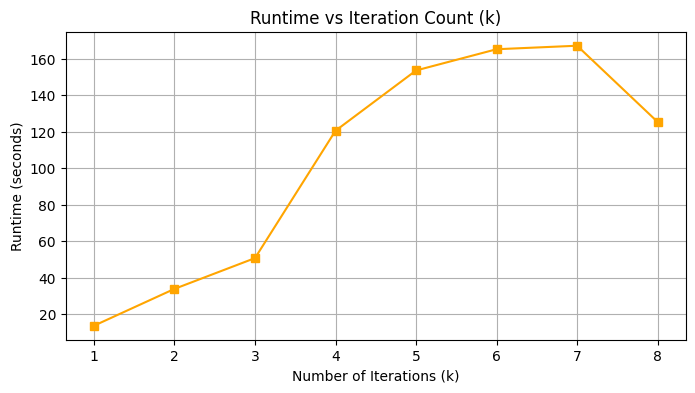

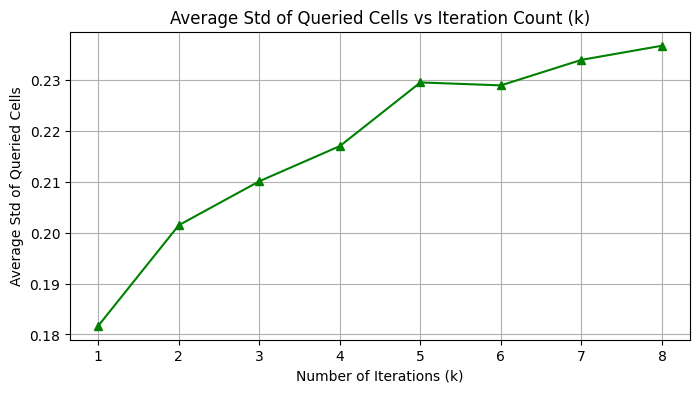

In [51]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

### Comparision

In [66]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 16,                # Tick labels
    "axes.labelsize": 20,          # Y-axis label
    "axes.labelweight": "bold",    # Bold axis label
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "axes.titlesize": 18
})

plt.figure(figsize=(6.5, 5))  # This is the likely size of the figure


<Figure size 650x500 with 0 Axes>

<Figure size 650x500 with 0 Axes>

MCAR Budget 0.1

In [77]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 100, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT", "OT-RandomFix", "OT-OneShot"]
all_results_comparision_mcar_b01 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b01.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-RandomFix"] = round(mae_random, 4)
    all_results_comparision_mcar_b01.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-RandomFix",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["OT-OneShot"] = round(mae_active, 4)
    all_results_comparision_mcar_b01.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-OneShot",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b01 = pd.DataFrame(all_results_comparision_mcar_b01)
df_mae_summary_comparision_mcar_b01 = df_comparision_mcar_b01.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b01 .to_string(index=False))



=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1896
OT-RandomFix 0.2072
        MICE 0.2314
          OT 0.2400
         KNN 0.2453
        Mean 0.2535

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1863
OT-RandomFix 0.2071
        MICE 0.2283
          OT 0.2308
         KNN 0.2383
        Mean 0.2467

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1901
OT-RandomFix 0.2084
          OT 0.2375
         KNN 0.2428
        Mean 0.2464
        MICE 0.2726

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Runnin

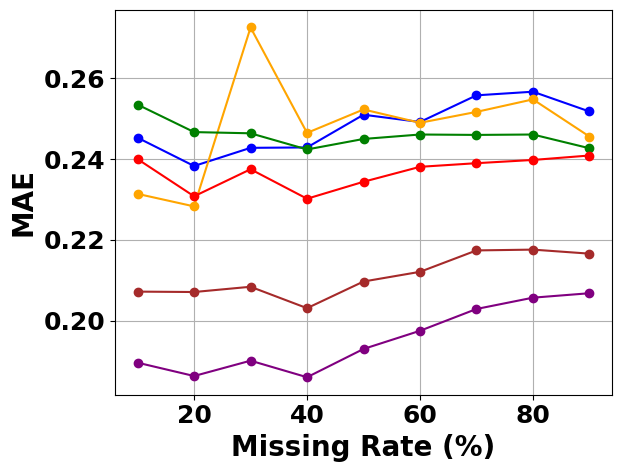

In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT": "red",
    "OT-RandomFix": "brown",
    "OT-OneShot": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b01.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b01["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b01[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_comparision_mcar_b01.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


MCAR Budget 0.2

In [79]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 100, 10)
budget_fraction = 0.2
methods = ["Mean", "KNN", "MICE", "OT", "OT-RandomFix", "OT-OneShot"]
all_results_comparision_mcar_b02 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b02.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-RandomFix"] = round(mae_random, 4)
    all_results_comparision_mcar_b02.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-RandomFix",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["OT-OneShot"] = round(mae_active, 4)
    all_results_comparision_mcar_b02.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-OneShot",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b02 = pd.DataFrame(all_results_comparision_mcar_b02)
df_mae_summary_comparision_mcar_b02 = df_comparision_mcar_b02.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b02 .to_string(index=False))



=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1561
OT-RandomFix 0.1803
        MICE 0.2253
          OT 0.2300
         KNN 0.2326
        Mean 0.2464

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1518
OT-RandomFix 0.1803
        MICE 0.2274
          OT 0.2283
         KNN 0.2336
        Mean 0.2441

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1533
OT-RandomFix 0.1845
          OT 0.2236
         KNN 0.2346
        Mean 0.2434
        MICE 0.2570

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Runnin

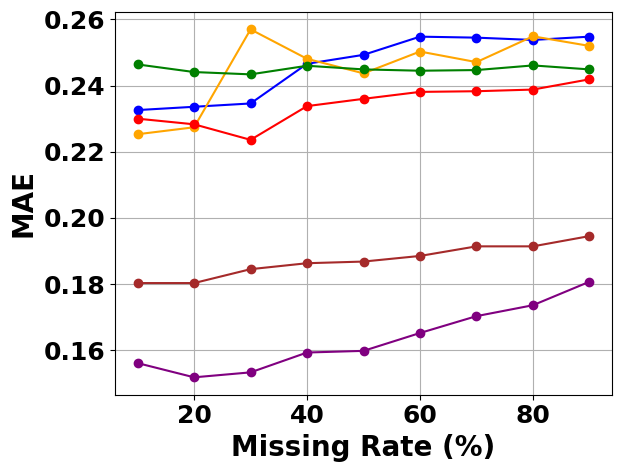

In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT": "red",
    "OT-RandomFix": "brown",
    "OT-OneShot": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b02.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b02["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b02[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_comparision_mcar_b02.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


MCAR Budget 0.3

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 100, 10)
budget_fraction = 0.3
methods = ["Mean", "KNN", "MICE", "OT", "OT-RandomFix", "OT-OneShot"]
all_results_comparision_mcar_b03 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b03.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-RandomFix"] = round(mae_random, 4)
    all_results_comparision_mcar_b03.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-RandomFix",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["OT-OneShot"] = round(mae_active, 4)
    all_results_comparision_mcar_b03.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-OneShot",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b03 = pd.DataFrame(all_results_comparision_mcar_b03)
df_mae_summary_comparision_mcar_b03 = df_comparision_mcar_b03.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b03 .to_string(index=False))



=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
  OT-OneShot 0.1157
OT-RandomFix 0.1530
        MICE 0.2132
          OT 0.2171
         KNN 0.2213
        Mean 0.2344

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Running OT-RandomFix...
Running OT-ActiveOT...


In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT": "red",
    "OT-RandomFix": "brown",
    "OT-OneShot": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b03.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b03["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b03[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\German_comparision_mcar_b03.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")
